# Analyzing Open Problems results in a smaller scope

- Using the newest run (2025.10.11) results
- 6 Datasets
    - mouse pancreas atlas
    - diabetic kidney disease
    - immune cell atlas
    - gtex_vg
    - hypomap
    - tabula sapiens   
    
  including following dataset features:
    - organism
    - n_tissues
    - size
    - n_genes
    - n_celltypes
    - n_batches
    - batch_imbalance (Coeffiecient of Variance)
    - nested_batch
    - n_donors
    - n_samples
- The metric `kBET` will be excluded since it fails when running on mouse pancreas atlas
- `HVG overlap` will be excluded as it is only computed for very few methods
- Methods that fail often or consistantly perform poorly are excluded (below (and including) BBKNN)

## setting up the packages and dataframe

In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


In [78]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [79]:
# Step 2 — Create one big DataFrame
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

In [80]:
# adding dataset metadata to the dataframe
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

In [81]:
# control methods - flags
control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
) # easier for plotting: control vs non-control

In [82]:
# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

In [84]:
# add a column dividing bio- and batch- metrics
bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

Sub-dataframe per metric for plotting:

In [85]:
for metric in df["metric_id"].unique():
    globals()[f"df_{metric}"] = df[df["metric_id"] == metric].sort_values("size")

## Helper functions for plotting

In [113]:
# For each integration method, does this dataset feature (e.g. n_genes, size, batch imbalance…) have a monotone relationship with the method's metric values?
def spearman_by_method(df_metric, feature, plot=True, save="", palette="viridis"):
    correlations = []

    for method in df_metric["method_id"].unique():
        df_m = df_metric[df_metric["method_id"] == method]

        if len(df_m) < 2:
            continue

        # Drop NaNs only for the correlation calculation
        valid = df_m[[feature, "metric_value"]].dropna()

        if len(valid) < 2:
            rho, pval = np.nan, np.nan
        else:
            rho, pval = spearmanr(valid[feature], valid["metric_value"])

        correlations.append({
            "method": method,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
            "control_group": df_m.loc[df_m["method_id"] == method, "control_group"].iloc[0]
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)

    # ---------- PLOT ----------
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="method",
            orient="h",
            hue="control_group",
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Method-level spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Method")
        plt.tight_layout()  
        
        if save != "":
            plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')
            
        plt.show()

    return corr_df

In [115]:
# For each evaluation metric (ARI, NMI, kBET, ASW, etc.), does this dataset feature show a monotone relationship with metric values?

def spearman_by_metric(df_metric, feature, plot=True, save="", palette="tab10"):
    correlations = []

    for metric in df_metric["metric_id"].unique():
        df_m = df_metric[df_metric["metric_id"] == metric]

        # Drop NaNs only for correlation
        valid = df_m[[feature, "metric_value"]].dropna()
        if len(valid) < 2:
            rho, pval = np.nan, np.nan
        else:
            rho, pval = spearmanr(valid[feature], valid["metric_value"])

        correlations.append({
            "metric_id": metric,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
            # if your df has this:
            "metric_type": df_m["metric_type"].iloc[0] if "metric_type" in df_m else None,
            "feature": feature,
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)
        
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="metric_id",
            orient="h",
            hue="metric_type" if "metric_type" in corr_df else None,
            palette=palette
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Metric-level spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Metric")
        plt.tight_layout()
        
        if save != "":
            plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

        plt.show()
        
    return corr_df


def spearman_by_metric_multi(df_metric, features, n_cols=3, height=4, save=""):
    dfs = []
    for feat in features:
        corr_df = spearman_by_metric(df_metric, feat, plot=False, save=False)
        dfs.append(corr_df)

    df_all = pd.concat(dfs, ignore_index=True)

    # Alphabetical ordering
    all_metrics = sorted(df_all["metric_id"].unique())

    n_features = len(features)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, height * n_rows),
        squeeze=False
    )

    for i, feat in enumerate(features):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r, c]

        df_feat = df_all[df_all["feature"] == feat].copy()
        df_feat = df_feat.sort_values("metric_id")

        sns.barplot(
            data=df_feat,
            y="metric_id",
            x="spearman_rho",
            order=all_metrics,
            hue="metric_id",        # <–– required to allow palette
            palette="tab20",
            legend=False,           # <–– hides the hue legend
            orient="h",
            ax=ax,
        )

        ax.axvline(0, color="grey", lw=1)
        ax.set_title(feat)
        ax.set_xlabel("Spearman ρ")
        ax.set_ylabel("Metric")

    # Hide empty axes
    for j in range(i + 1, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axes[r, c].set_visible(False)

    plt.tight_layout()
        
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

    plt.show()

    return df_all


In [116]:
# different points per method -> error bar
def spearman_per_metric_across_methods(df, feature, palette="tab20", save=""):
    """
    For a given feature column, compute Spearman(feature, metric_value)
    for each metric_id × method_id pair, then plot a pointplot:

      x-axis: metric_id
      y-axis: mean Spearman rho across methods
      error bars: SD across methods
      color: metric_type (bio / batch / baseline)

    Assumes df has columns:
      - metric_id
      - method_id
      - metric_value
      - <feature> (name passed as `feature`)
      - metric_type (for hue)
    """
    rows = []

    # ----- compute rho per metric × method -----
    for metric in df["metric_id"].unique():
        df_metric = df[df["metric_id"] == metric]

        for method in df_metric["method_id"].unique():
            df_mm = df_metric[df_metric["method_id"] == method][[feature, "metric_value"]].dropna()

            # need at least 2 points
            if len(df_mm) < 2:
                continue

            # skip constant inputs (Spearman undefined)
            if df_mm[feature].nunique() < 2 or df_mm["metric_value"].nunique() < 2:
                continue

            rho, _ = spearmanr(df_mm[feature], df_mm["metric_value"])

            rows.append({
                "metric_id": metric,
                "method_id": method,
                "spearman_rho": rho,
                "metric_type": df_metric["metric_type"].iloc[0] if "metric_type" in df_metric else None
            })

    corr = pd.DataFrame(rows)

    if corr.empty:
        print("No valid correlations (all constant inputs or too few points).")
        return None
    
    summary = (
        corr.groupby(["metric_id", "metric_type"])["spearman_rho"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("mean", ascending=False)
    )

    # ----- PLOT: metric_id on x-axis, error bars from SD across methods -----
    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=corr,
        x="metric_id",          # metric on x-axis
        y="spearman_rho",
        hue="metric_type",
        errorbar="sd",          # SD across methods
        dodge=True,
        linestyles="none",      # no lines between points
        palette=palette,
    )

    plt.axhline(0, color="black", lw=1)
    plt.xlabel("Metric")
    plt.ylabel("Spearman ρ (feature vs metric_value)")
    plt.title(f"Metric-level Spearman correlation with {feature}\n(mean ± SD across methods)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')
    
    plt.show()

    return summary, corr


In [117]:
def metric_vs_feature_by_method_facet(
    df,
    feature,
    title="",
    metric_col="metric_id",
    y_col="metric_value",
    height=3.2,
    col_wrap=4,
    sharex=True,
    sharey=False,
    save="",
):
    """
    Facet by metric, hue by method, using FacetGrid + regplot.
    Includes correct legend with color + linestyle.
    """

    if df.empty:
        print(f"[plot_metric_vs_feature_by_method_facet] No data to plot for: {title}")
        return

    if feature not in df.columns:
        raise ValueError(f"Feature '{feature}' not in dataframe columns.")

    # Consistent ordering
    metric_order = sorted(df[metric_col].unique())
    method_order = sorted(df["method_id"].unique())

    # Assign colors and linestyles
    palette = sns.color_palette("tab20", n_colors=len(method_order))
    line_styles = ["-", "--", ":", "-."]

    method_to_color = dict(zip(method_order, palette))
    method_to_style = {
        m: line_styles[i % len(line_styles)] for i, m in enumerate(method_order)
    }

    # FacetGrid (hue is defined but regplot ignores it; we use for mapping)
    g = sns.FacetGrid(
        df,
        col=metric_col,
        hue="method_id",
        col_wrap=col_wrap,
        height=height,
        col_order=metric_order,
        hue_order=method_order,
        sharex=sharex,
        sharey=sharey,
    )

    # Plot function using manual color + linestyle
    def reg_with_style(data, color, **kwargs):
        method = data["method_id"].iloc[0]
        style = method_to_style[method]

        sns.regplot(
            data=data,
            x=feature,
            y=y_col,
            ci=None,
            scatter=True,
            color=method_to_color[method],
            scatter_kws={"s": 20, "alpha": 0.6},
            line_kws={"linewidth": 1.5, "linestyle": style},
        )

    g.map_dataframe(reg_with_style)

    # --------- LEGEND (manual color + line style) ----------
    handles = [
        Line2D(
            [0], [0],
            color=method_to_color[m],
            linestyle=method_to_style[m],
            linewidth=2,
            marker="o",
            markersize=5,
            label=m,
        )
        for m in method_order
    ]

    g.add_legend(handles=handles, title="method_id")

    # Labels & titles
    g.set_axis_labels(feature, y_col)
    g.set_titles(col_template="{col_name}")
    g.fig.subplots_adjust(top=0.9)
    if title:
        g.fig.suptitle(title, y=1.02)
        
    if save != "":
        plt.savefig(f"/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/{save}.png", dpi=300, bbox_inches='tight')

    plt.show()


## Correlation between one metric and one feature (per method)

- spearman correlation bar plot to see which methods to focus on
    - a line plot connecting each methods per metric-feature would be nice to look together as well
- high correlation & visible linear relation -> linear regression
- no, actually just lm plot straight away?
- take one postive control method, one negative, and one integration method that I understand so that I have an expectation
    - scvi, harmony, scanorama
- random effect: method
- if I don’t see a linear trend: move on to the next metric; maybe there’s a way to see them all at once as well idk
- if the method is a control method, the line is coloured orange, if not, blue

- will take correlation value higher than 0.8 as correlated

### ari vs size - combat, batchelor_fastmnn, liger, harmonypy,

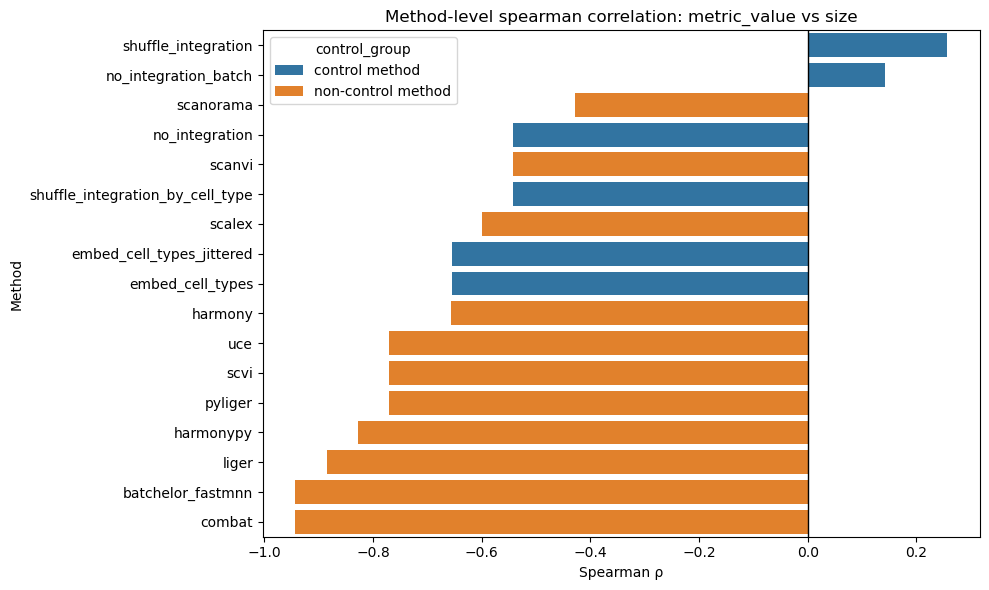

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.257143,0.622787,6,control method
10,no_integration_batch,0.142857,0.787172,6,control method
0,scanorama,-0.428571,0.396501,6,non-control method
1,no_integration,-0.542857,0.265703,6,control method
11,scanvi,-0.542857,0.265703,6,non-control method
12,shuffle_integration_by_cell_type,-0.542857,0.265703,6,control method
3,scalex,-0.600000,0.208000,6,non-control method
7,embed_cell_types_jittered,-0.654654,0.158302,6,control method
13,embed_cell_types,-0.654654,0.158302,6,control method
5,harmony,-0.657143,0.156175,6,non-control method


In [16]:
spearman_by_method(df_ari, "size")

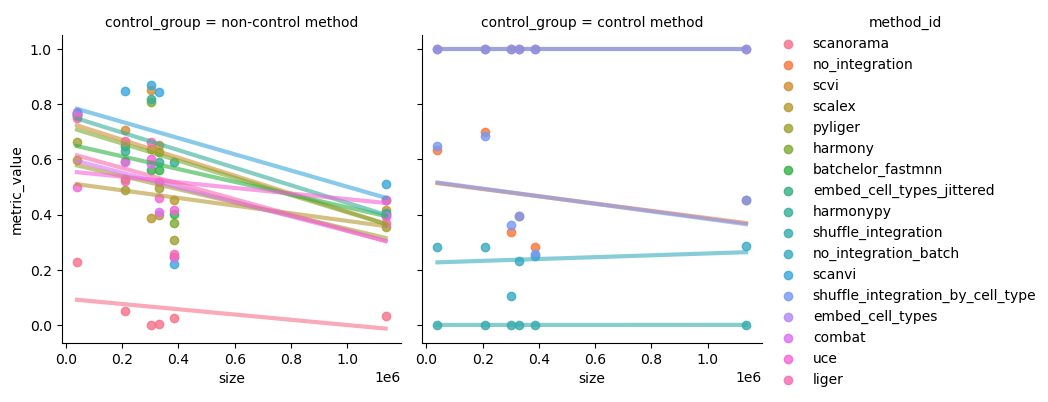

In [18]:
sns.lmplot(data=df_ari, x="size", y="metric_value", hue="method_id", col="control_group", 
           height=4, ci=None, line_kws={'alpha': 0.6, 'linewidth': 3})

lines overlap so use FacetGrid + regplot

In [21]:
palette = sns.color_palette("tab20")

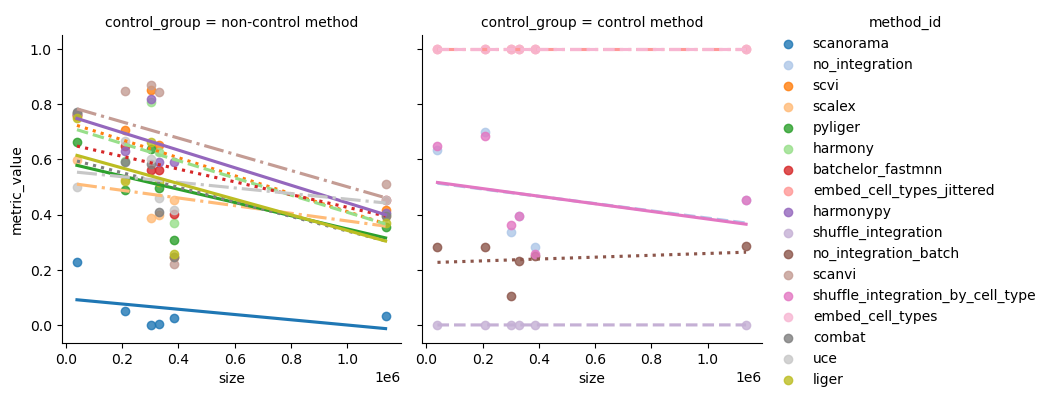

In [22]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="size",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_genes - scanvi, harmonypy, uce, scvi

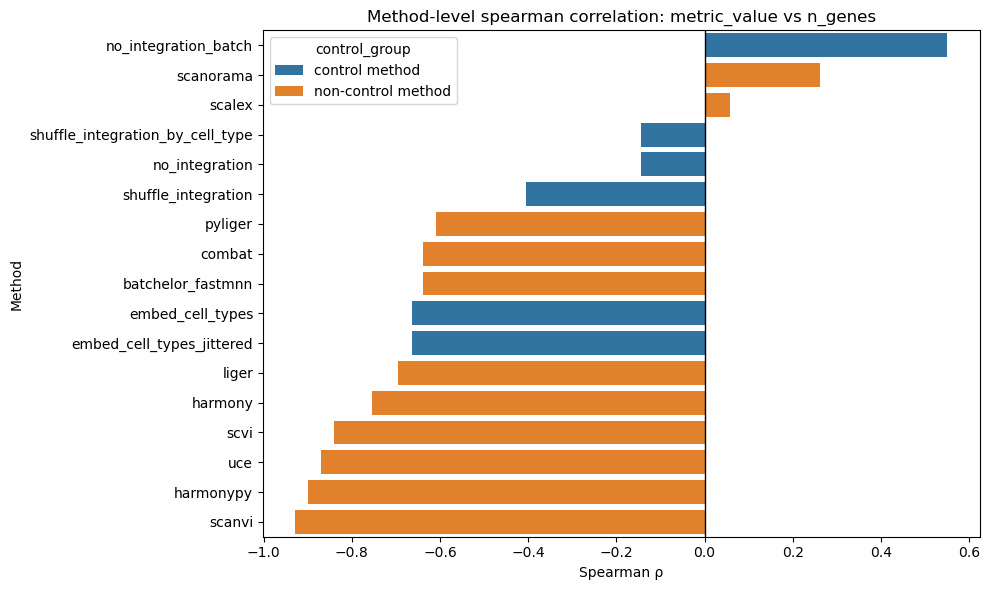

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.550782,0.257369,6,control method
0,scanorama,0.260897,0.617534,6,non-control method
3,scalex,0.057977,0.913132,6,non-control method
12,shuffle_integration_by_cell_type,-0.144943,0.784108,6,control method
1,no_integration,-0.144943,0.784108,6,control method
9,shuffle_integration,-0.405840,0.424663,6,control method
4,pyliger,-0.608760,0.199660,6,non-control method
14,combat,-0.637748,0.173071,6,non-control method
6,batchelor_fastmnn,-0.637748,0.173071,6,non-control method
13,embed_cell_types,-0.664211,0.150200,6,control method


In [23]:
spearman_by_method(df_ari, "n_genes")

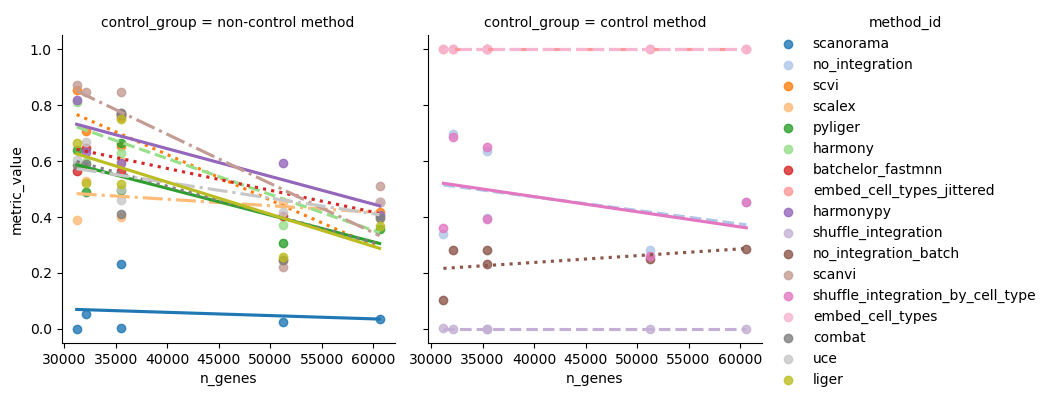

In [24]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_genes",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

one trend for one metric&method - look if other metrics show that trend too

### ari vs n_tissues - no high correlation

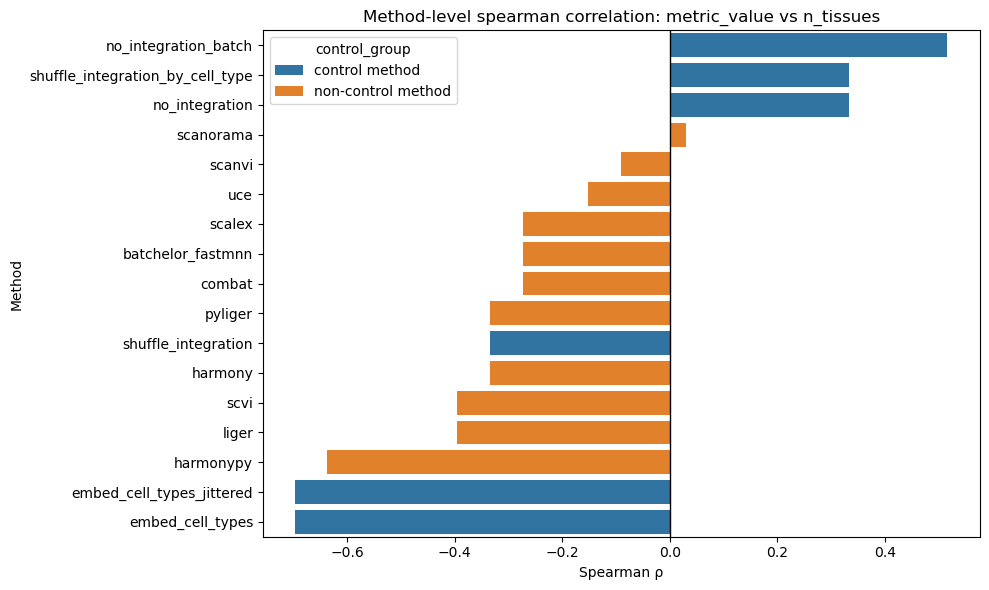

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.516100,0.294584,6,control method
12,shuffle_integration_by_cell_type,0.333947,0.517700,6,control method
1,no_integration,0.333947,0.517700,6,control method
0,scanorama,0.030359,0.954476,6,non-control method
11,scanvi,-0.091077,0.863763,6,non-control method
15,uce,-0.151794,0.774058,6,non-control method
3,scalex,-0.273230,0.600355,6,non-control method
6,batchelor_fastmnn,-0.273230,0.600355,6,non-control method
14,combat,-0.273230,0.600355,6,non-control method
4,pyliger,-0.333947,0.517700,6,non-control method


In [25]:
spearman_by_method(df_ari, "n_tissues")

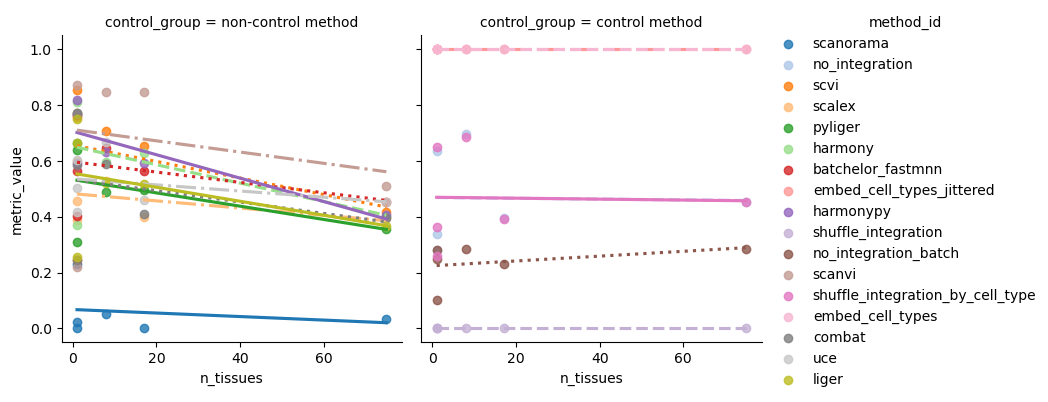

In [26]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_tissues",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_celltypes - no high correlation

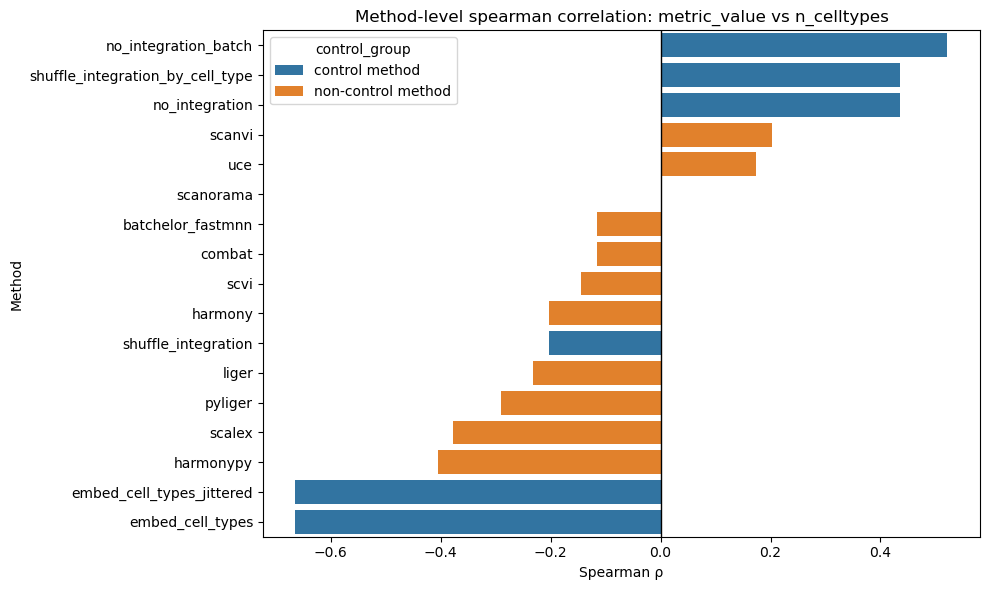

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.521794,0.288343,6,control method
12,shuffle_integration_by_cell_type,0.434828,0.388865,6,control method
1,no_integration,0.434828,0.388865,6,control method
11,scanvi,0.202920,0.699798,6,non-control method
15,uce,0.173931,0.741734,6,non-control method
0,scanorama,0.000000,1.000000,6,non-control method
6,batchelor_fastmnn,-0.115954,0.826848,6,non-control method
14,combat,-0.115954,0.826848,6,non-control method
2,scvi,-0.144943,0.784108,6,non-control method
5,harmony,-0.202920,0.699798,6,non-control method


In [27]:
spearman_by_method(df_ari, "n_celltypes")

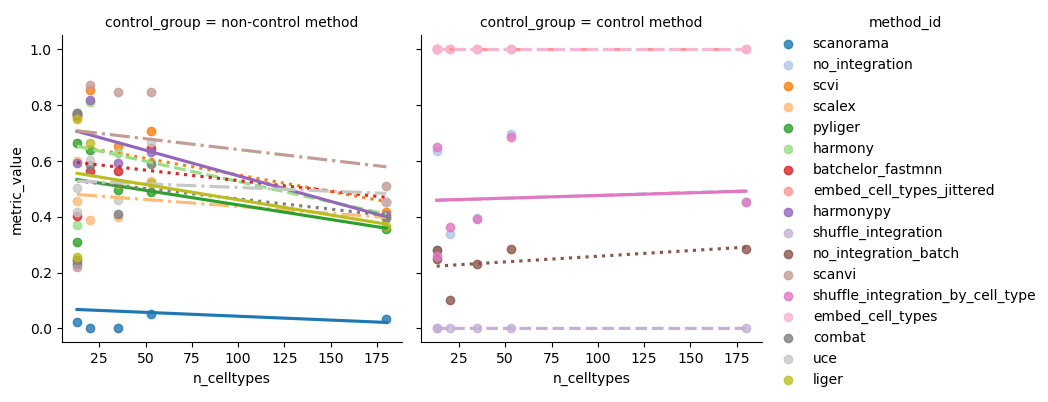

In [28]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_celltypes",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_batches - no high correlation

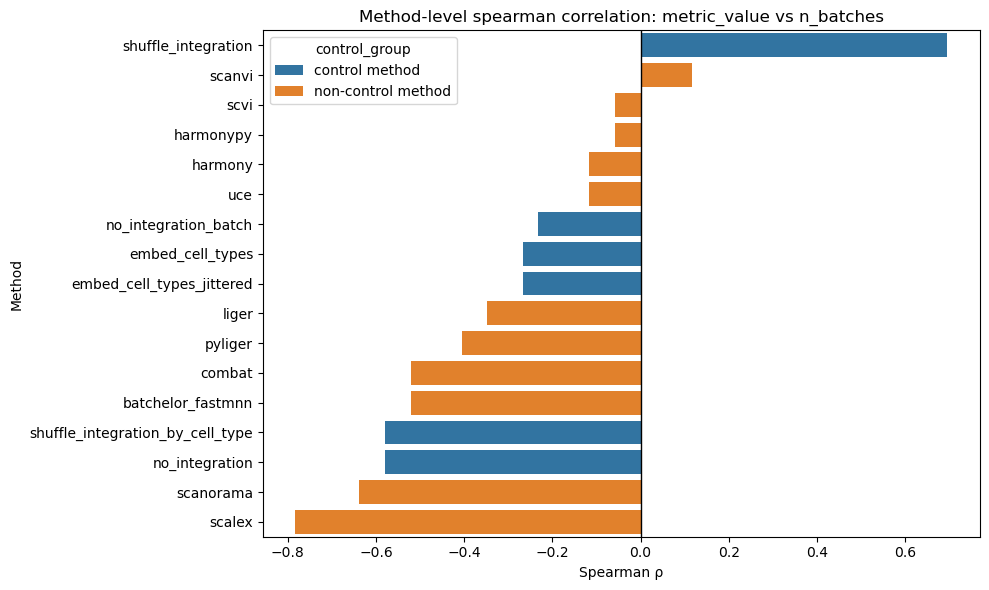

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.695725,0.124789,6,control method
11,scanvi,0.115954,0.826848,6,non-control method
2,scvi,-0.057977,0.913132,6,non-control method
8,harmonypy,-0.057977,0.913132,6,non-control method
5,harmony,-0.115954,0.826848,6,non-control method
15,uce,-0.115954,0.826848,6,non-control method
10,no_integration_batch,-0.231908,0.658374,6,control method
13,embed_cell_types,-0.265684,0.610850,6,control method
7,embed_cell_types_jittered,-0.265684,0.610850,6,control method
16,liger,-0.347863,0.499253,6,non-control method


In [29]:
spearman_by_method(df_ari, "n_batches")

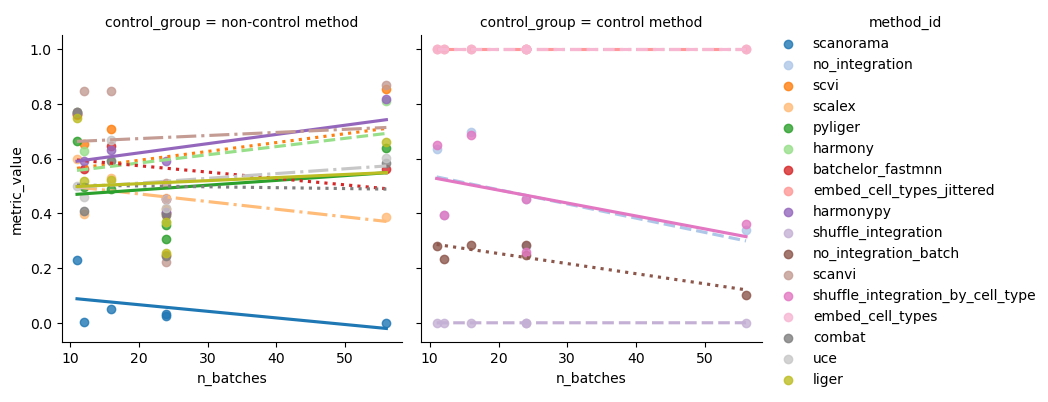

In [30]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_batches",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs batch_imbalance (CV) - pyliger, liger, harmony, scvi, harmonypy, combat, batchelor_fastmnn

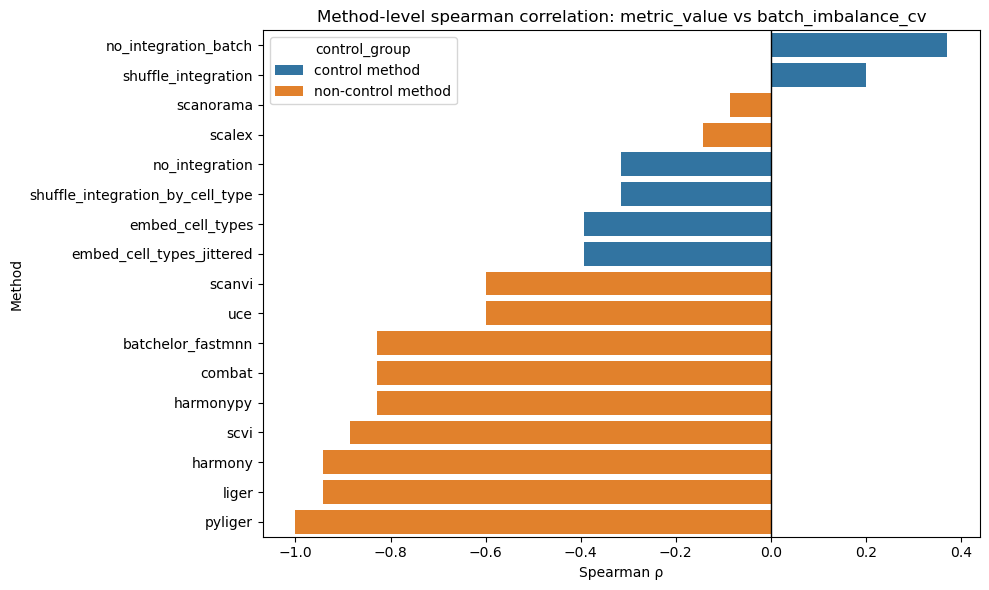

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.371429,0.468478,6,control method
9,shuffle_integration,0.200000,0.704000,6,control method
0,scanorama,-0.085714,0.871743,6,non-control method
3,scalex,-0.142857,0.787172,6,non-control method
1,no_integration,-0.314286,0.544093,6,control method
12,shuffle_integration_by_cell_type,-0.314286,0.544093,6,control method
13,embed_cell_types,-0.392792,0.441113,6,control method
7,embed_cell_types_jittered,-0.392792,0.441113,6,control method
11,scanvi,-0.600000,0.208000,6,non-control method
15,uce,-0.600000,0.208000,6,non-control method


In [31]:
spearman_by_method(df_ari, "batch_imbalance_cv")

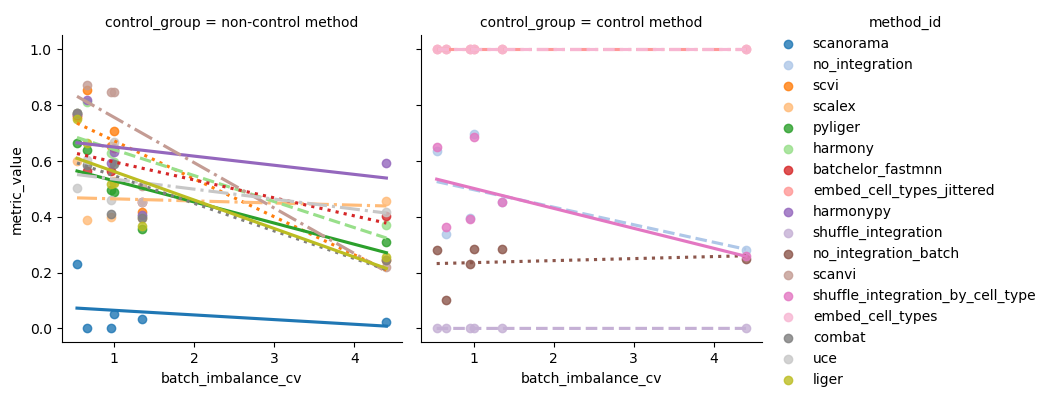

In [35]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="batch_imbalance_cv",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs batch_imbalance_gc (gini coefficient)

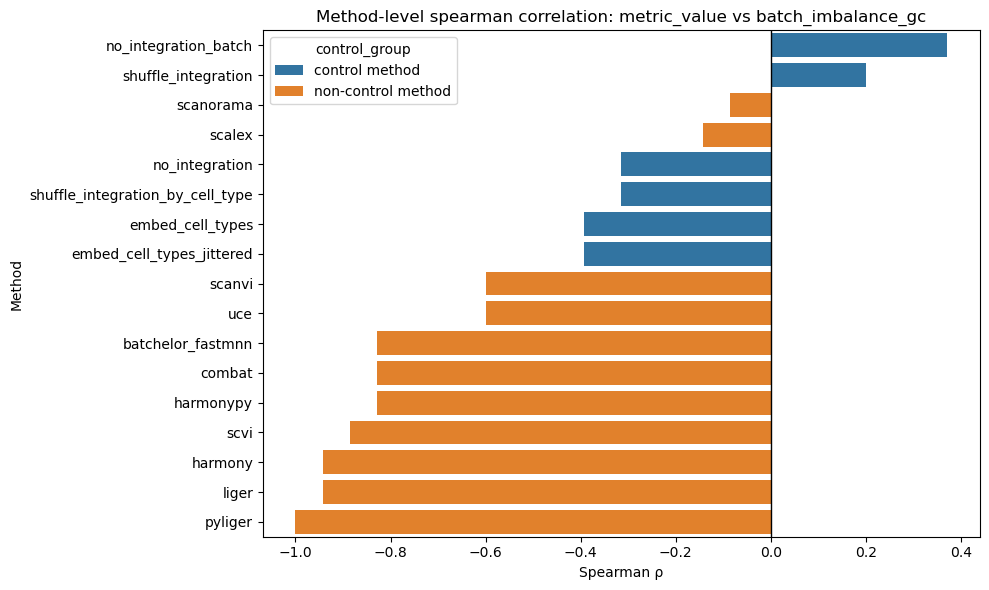

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.371429,0.468478,6,control method
9,shuffle_integration,0.200000,0.704000,6,control method
0,scanorama,-0.085714,0.871743,6,non-control method
3,scalex,-0.142857,0.787172,6,non-control method
1,no_integration,-0.314286,0.544093,6,control method
12,shuffle_integration_by_cell_type,-0.314286,0.544093,6,control method
13,embed_cell_types,-0.392792,0.441113,6,control method
7,embed_cell_types_jittered,-0.392792,0.441113,6,control method
11,scanvi,-0.600000,0.208000,6,non-control method
15,uce,-0.600000,0.208000,6,non-control method


In [36]:
spearman_by_method(df_ari, "batch_imbalance_gc")

CG and Gini return same correlation value:

They are the same because CV and Gini are almost perfectly monotonic transformations of each other for non-negative, skewed, count-like batch-size distributions.
Spearman correlation only cares about rank order, not numeric values—so if two measures rank items identically, they will give exactly the same Spearman correlation with any metric.

### ari vs nested_batches - uce, scanvi

nested_batches is categorical, but binary - map to 0 (No) and 1 (Yes). Then:

- Positive Spearman → “Yes” group tends to have higher values”
- Negative Spearman → “No” group tends to have higher values”
- Magnitude near 1 or –1 → groups are strongly separated
- Magnitude near 0 → no monotonic relationship


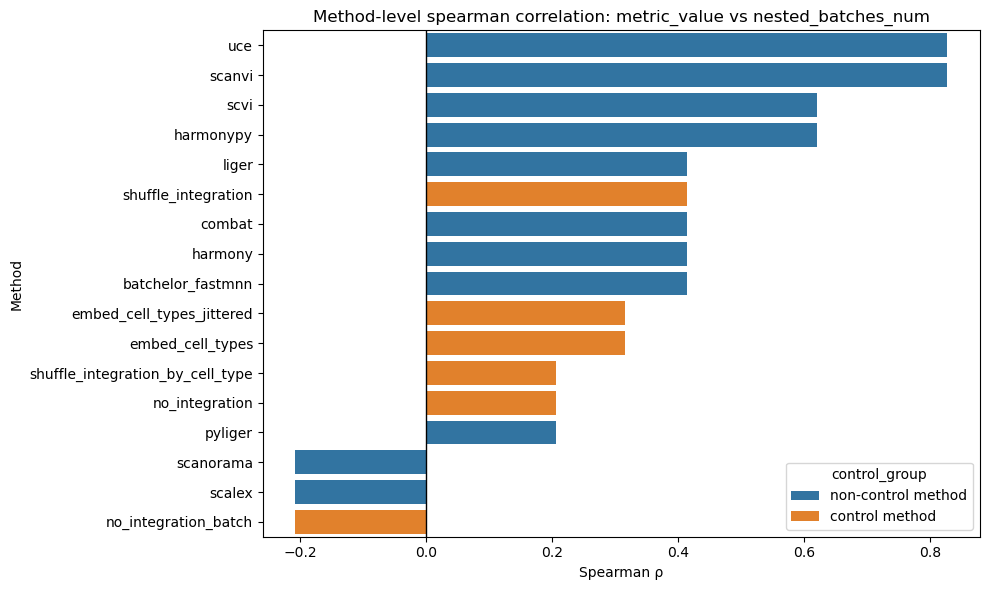

,method,spearman_rho,p_value,n_points,control_group
15,uce,0.828079,0.041795,6,non-control method
11,scanvi,0.828079,0.041795,6,non-control method
2,scvi,0.621059,0.188187,6,non-control method
8,harmonypy,0.621059,0.188187,6,non-control method
16,liger,0.414039,0.414430,6,non-control method
9,shuffle_integration,0.414039,0.414430,6,control method
14,combat,0.414039,0.414430,6,non-control method
5,harmony,0.414039,0.414430,6,non-control method
6,batchelor_fastmnn,0.414039,0.414430,6,non-control method
7,embed_cell_types_jittered,0.316228,0.541470,6,control method


In [37]:
spearman_by_method(df_ari, "nested_batches_num")

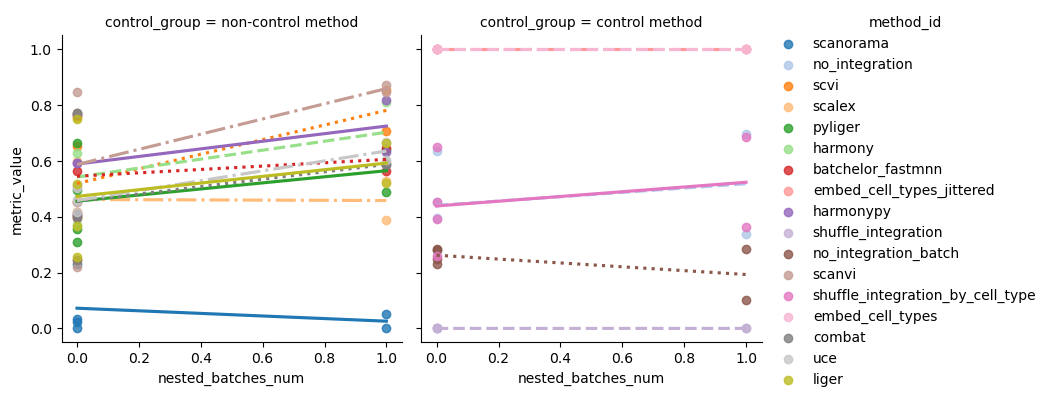

In [38]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="nested_batches_num",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_samples - combat, batchelor_fastmnn, pyliger, liger

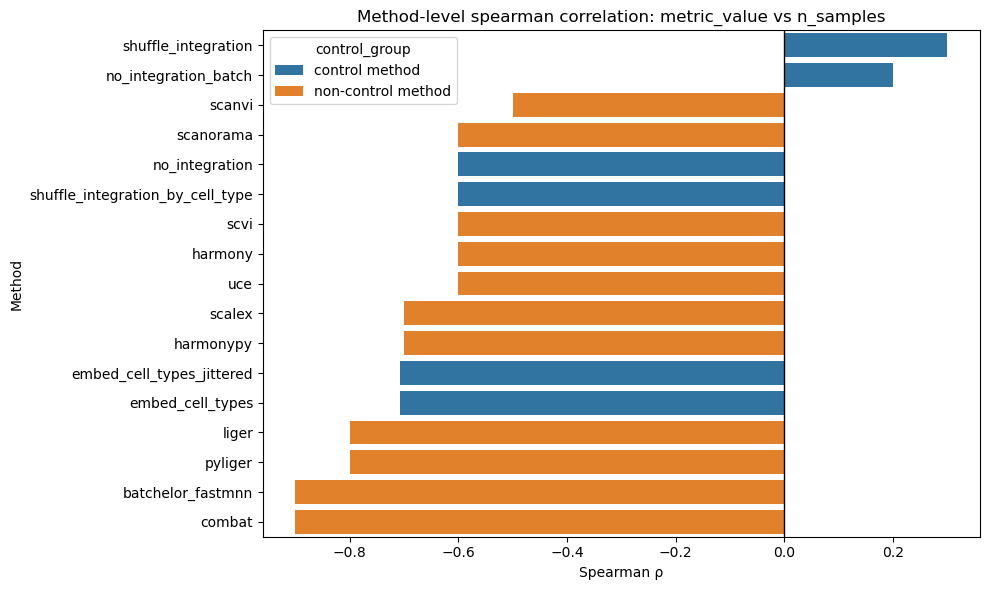

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.300000,0.623838,6,control method
10,no_integration_batch,0.200000,0.747060,6,control method
11,scanvi,-0.500000,0.391002,6,non-control method
0,scanorama,-0.600000,0.284757,6,non-control method
1,no_integration,-0.600000,0.284757,6,control method
12,shuffle_integration_by_cell_type,-0.600000,0.284757,6,control method
2,scvi,-0.600000,0.284757,6,non-control method
5,harmony,-0.600000,0.284757,6,non-control method
15,uce,-0.600000,0.284757,6,non-control method
3,scalex,-0.700000,0.188120,6,non-control method


In [39]:
spearman_by_method(df_ari, "n_samples")

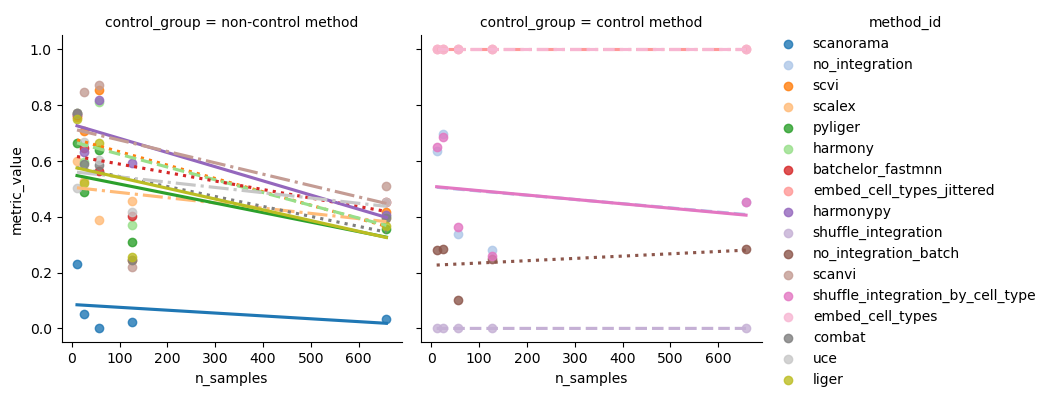

In [40]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_samples",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_donors - no high correlation

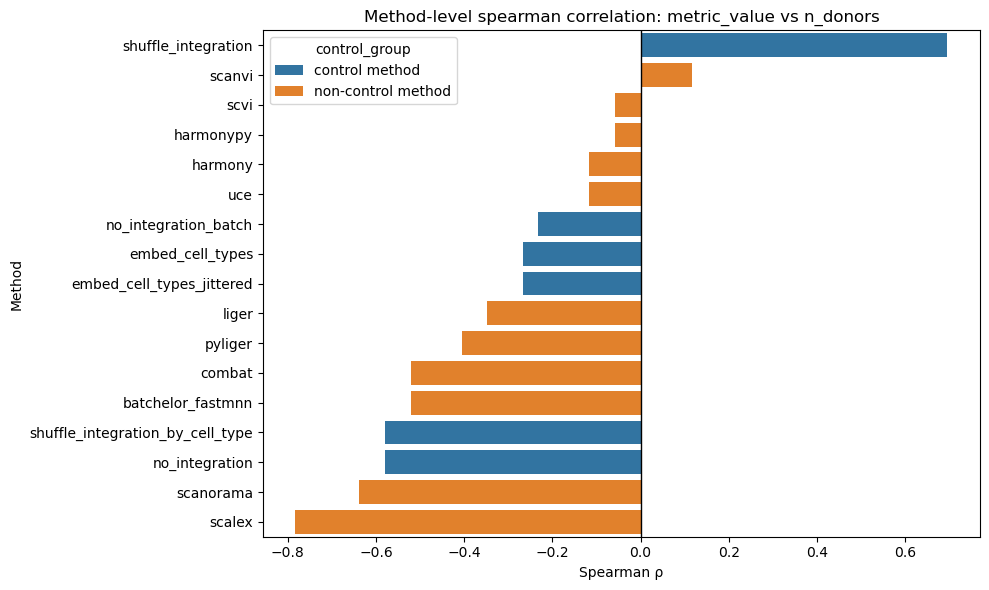

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.695725,0.124789,6,control method
11,scanvi,0.115954,0.826848,6,non-control method
2,scvi,-0.057977,0.913132,6,non-control method
8,harmonypy,-0.057977,0.913132,6,non-control method
5,harmony,-0.115954,0.826848,6,non-control method
15,uce,-0.115954,0.826848,6,non-control method
10,no_integration_batch,-0.231908,0.658374,6,control method
13,embed_cell_types,-0.265684,0.610850,6,control method
7,embed_cell_types_jittered,-0.265684,0.610850,6,control method
16,liger,-0.347863,0.499253,6,non-control method


In [41]:
spearman_by_method(df_ari, "n_donors")

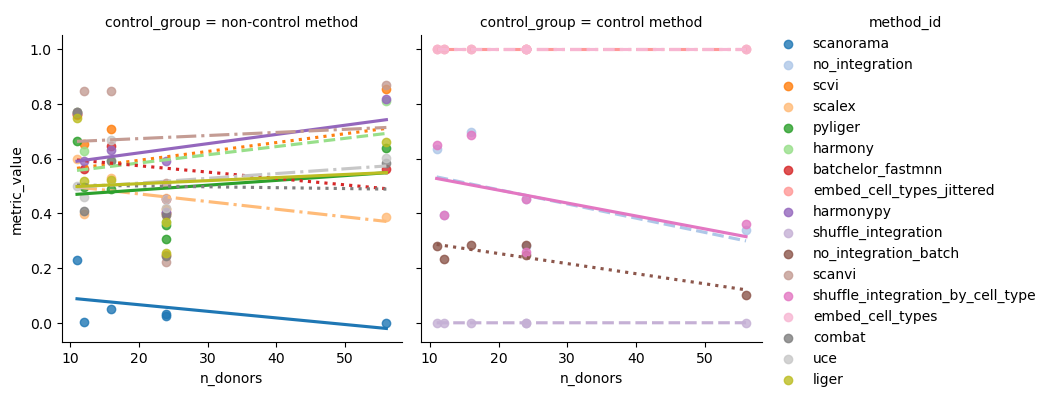

In [42]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_donors",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

## Trying to go one dimension higher?

### one metric x size per method - all together

In [98]:
# prepare for plotting 4 plots
df_plot = df.copy()

# Split baseline vs non-baseline
baseline = df_plot[df_plot["metric_type"] == "baseline"]
non_baseline = df_plot[df_plot["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df_plot = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

In [99]:
df_plot

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
0,gtex_v9,embed_cell_types,ilisi,0.116225,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
1,gtex_v9,embed_cell_types,clisi,1.000000,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
2,hypomap,batchelor_fastmnn,ilisi,0.000518,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
3,hypomap,batchelor_fastmnn,clisi,1.000000,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
4,mouse_pancreas_atlas,embed_cell_types_jittered,cell_cycle_conservation,0.681843,Mouse,1,301796,31202,20,56,0.66,0.354691,Yes,56.0,56,positive,control method,1,bio,bio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,tabula_sapiens,pyliger,ari_batch,0.960975,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1492,tabula_sapiens,pyliger,nmi_batch,0.886413,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1493,immune_cell_atlas,embed_cell_types_jittered,kbet_pg,0.274452,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,positive,control method,0,batch,batch
1494,gtex_v9,scalex,isolated_label_f1,0.016119,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,non-control,non-control method,1,bio,bio


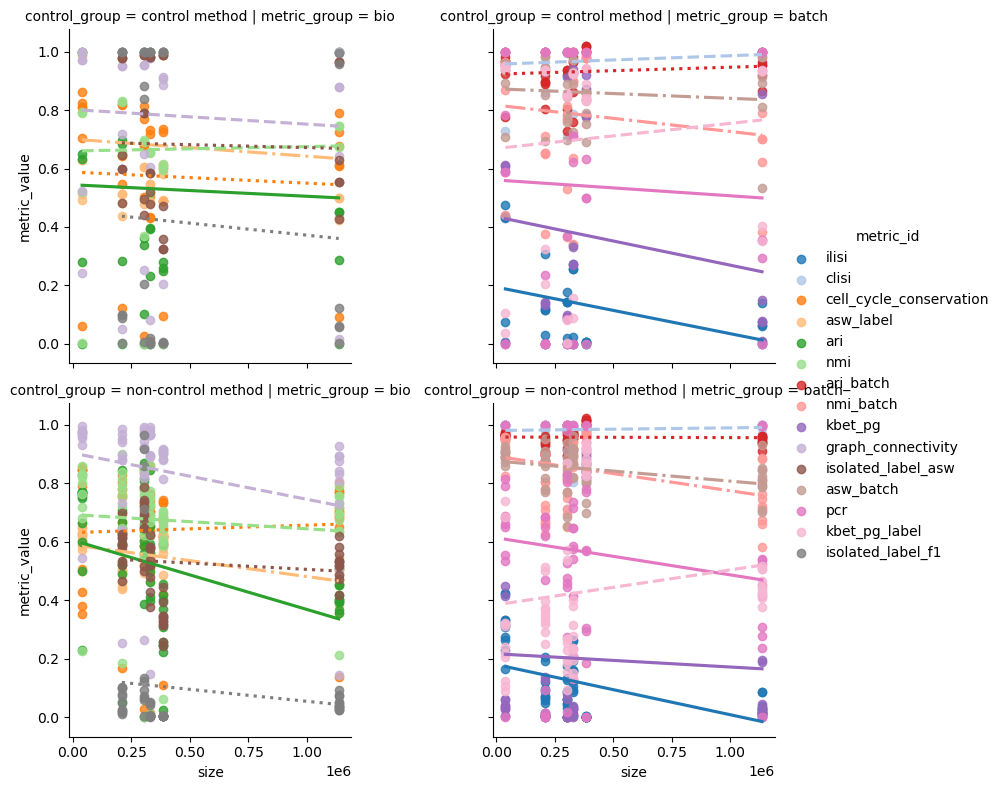

In [46]:
g = sns.FacetGrid(
    df_plot,
    row="control_group",         # control vs non-control
    col="metric_group",          # bio vs batch
    hue="metric_id",
    height=4,
    palette=palette,
    row_order=["control method", "non-control method"],
    col_order=["bio", "batch"],
    # subplot_kws={"wspace": 0.3},
)

def reg_with_style(data, color, label, **kwargs):
    # Use global df just to get consistent index for line_styles
    idx = list(df["metric_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="size",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={"linestyle": style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

g.fig.subplots_adjust(wspace=0.5)

g.savefig("/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/size_groupby_method_bio_batch.png", dpi=300)

The datapoints here are merthod x dataset for each metric(color)

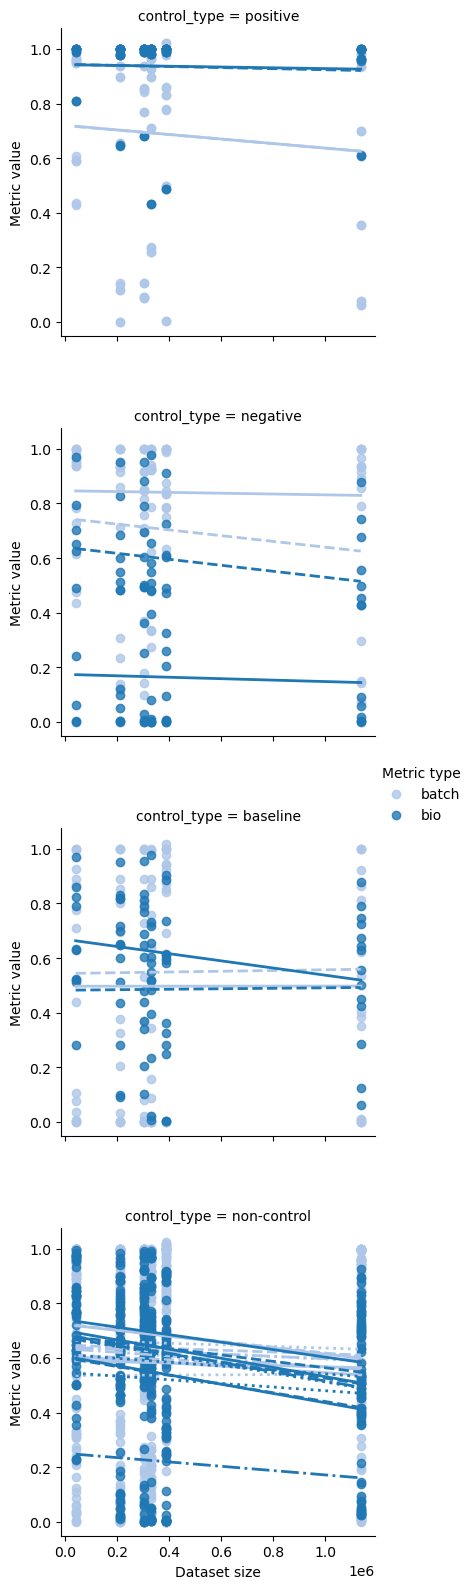

In [120]:
control_type_order = ["positive", "negative", "baseline", "non-control"]

# Optional: 2-color palette for bio vs batch
palette = {
    "bio": sns.color_palette("tab20")[0],
    "batch": sns.color_palette("tab20")[1],
}

g = sns.FacetGrid(
    df_plot,
    row="control_type",      # <-- facet ONLY by method type
    hue="metric_group",      # <-- color: bio vs batch
    height=4,
    palette=palette,
    row_order=control_type_order,
    sharex=True,
    sharey=True,
)

def reg_with_style(data, color, **kwargs):
    # one line per method_id inside this facet & hue
    for i, (method, df_m) in enumerate(data.groupby("method_id")):
        style = line_styles[i % len(line_styles)]
        sns.regplot(
            data=df_m,
            x="size",
            y="metric_value",
            color=color,         # color = metric_group
            ci=None,
            scatter=True,        # or False if you want only lines
            line_kws={"linestyle": style, "linewidth": 2},
            **kwargs
        )

g.map_dataframe(reg_with_style)

# Legend will show metric_group (bio / batch) from hue
g.add_legend(title="Metric type")

# Some spacing tweaks
g.set_axis_labels("Dataset size", "Metric value")
g.fig.subplots_adjust(hspace=0.3)

g.savefig(
    "/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/"
    "size_facet_by_control_type_line_by_method_hue_metric_group.png",
    dpi=300,
    bbox_inches="tight",
)


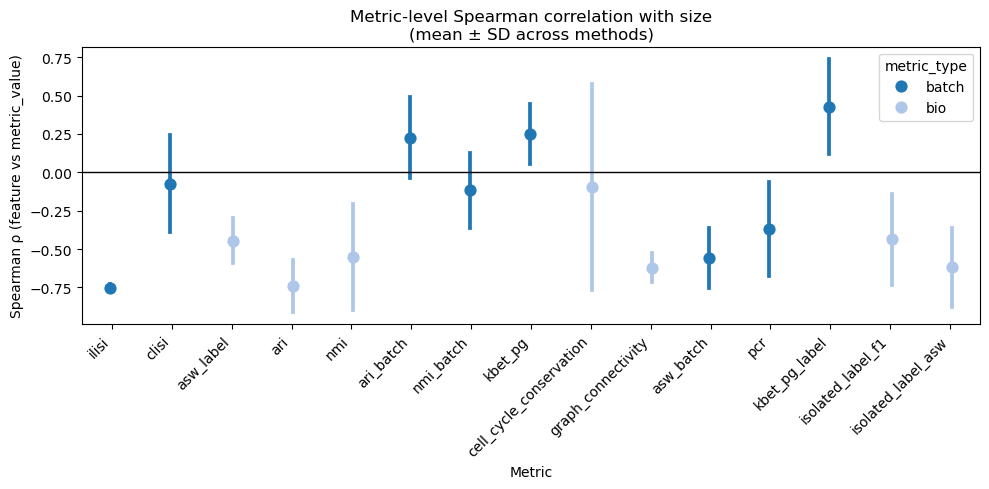

(                  metric_id metric_type      mean       std  count
 11            kbet_pg_label       batch  0.428571  0.307724     11
 10                  kbet_pg       batch  0.251948  0.195383     11
 1                 ari_batch       batch  0.225974  0.263556     11
 5                     clisi       batch -0.072898  0.314684     11
 4   cell_cycle_conservation         bio -0.096104  0.672160     11
 13                nmi_batch       batch -0.116883  0.245599     11
 14                      pcr       batch -0.370953  0.307347     11
 9         isolated_label_f1         bio -0.436364  0.297566     11
 3                 asw_label         bio -0.444156  0.144766     11
 12                      nmi         bio -0.553247  0.345531     11
 2                 asw_batch       batch -0.558442  0.194774     11
 8        isolated_label_asw         bio -0.618182  0.256196     11
 6        graph_connectivity         bio -0.620779  0.093102     11
 0                       ari         bio -0.7402

In [118]:
spearman_per_metric_across_methods(df_plot.query("control_group == 'non-control method'"), "size", save="spearman_with_size_noncotrol")

### one method x size per metric - all toghether

- one subplot per method
- bio and batch metrics separately
- control methods excluded

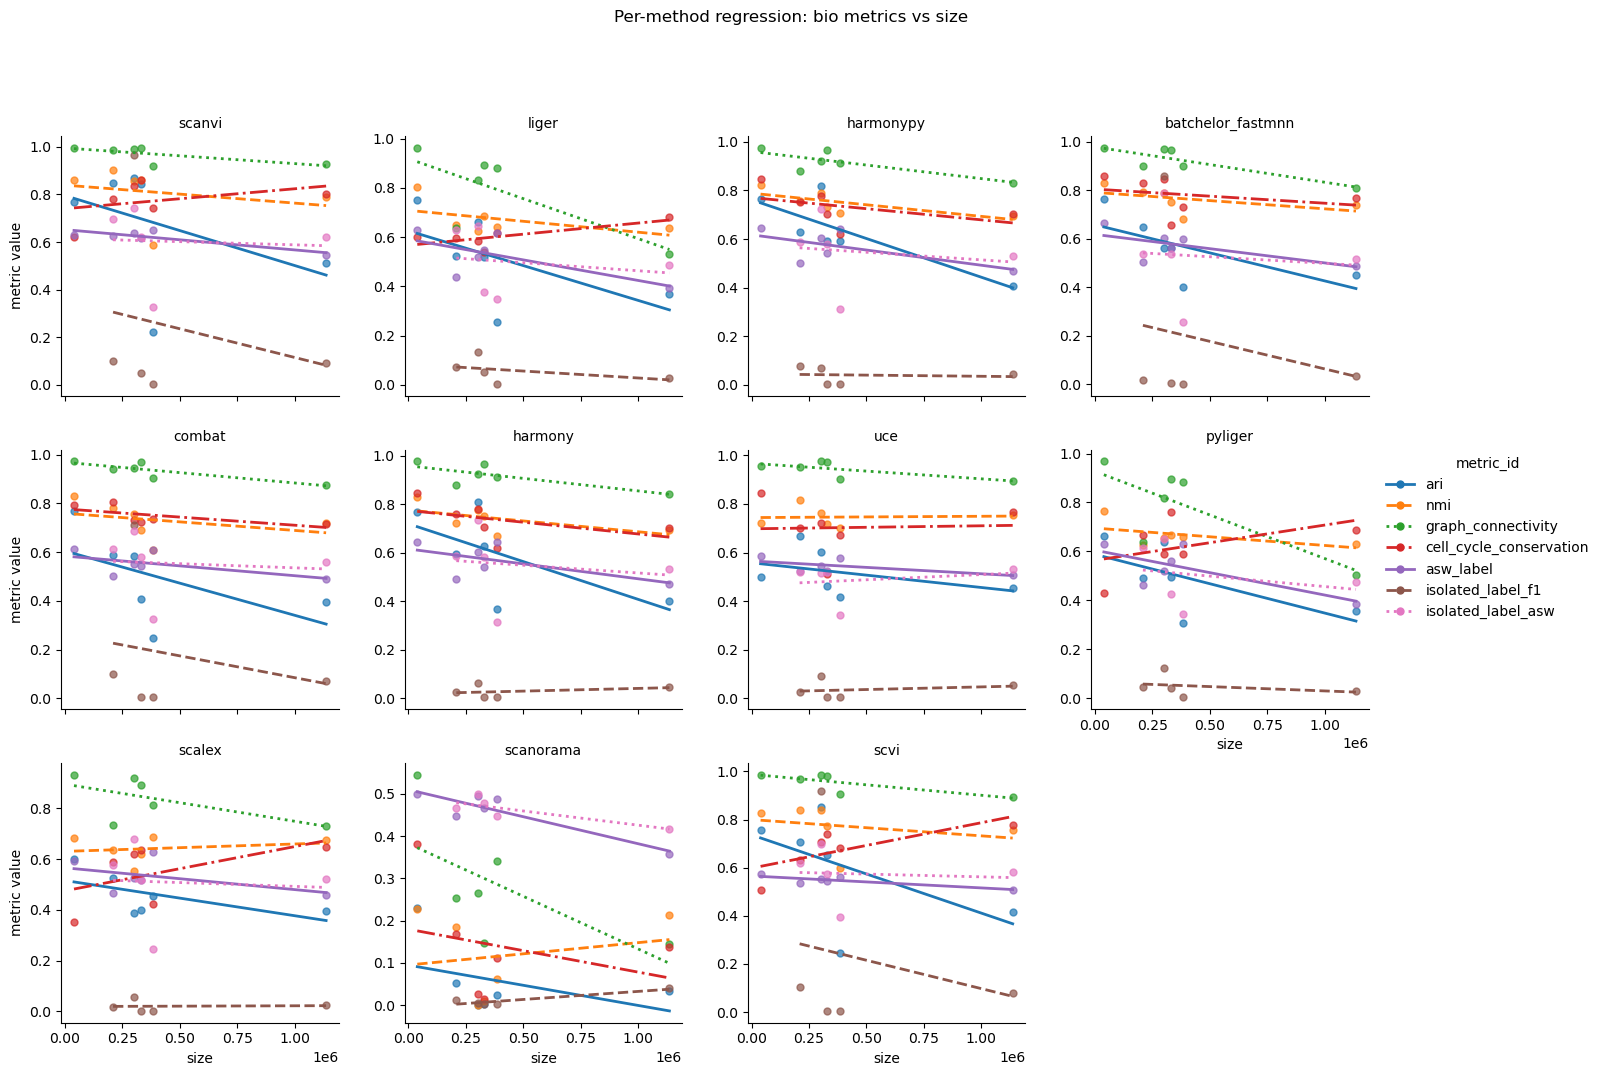

In [49]:
df_bio = df_plot.query("metric_type == 'bio'")
df_bio = df_bio[df_bio["control_group"] == "non-control method"]

metric_order = [m for m in bio_metrics if m in df_bio["metric_id"].unique()]
palette = sns.color_palette("tab10", n_colors=len(metric_order))
line_styles = ["-", "--", ":", "-."]

# map metric -> color
color_map = dict(zip(metric_order, palette))

# --------- FACETGRID WITHOUT HUE ----------
g = sns.FacetGrid(
    df_bio,
    col="method_id",
    col_wrap=4,
    height=3.5,
    sharex=True,
    sharey=False,
)

# --------- PLOT EACH METRIC MANUALLY ----------
def reg_all_metrics(data, **kwargs):
    # data = one method (facet)
    for i, metric in enumerate(metric_order):
        df_m = data[data["metric_id"] == metric]
        if df_m.empty:
            continue

        color = color_map[metric]
        style = line_styles[i % len(line_styles)]

        sns.regplot(
            data=df_m,
            x="size",
            y="metric_value",
            ci=None,
            scatter=True,
            color=color,   # YOUR color
            scatter_kws={"s": 25, "alpha": 0.7},
            line_kws={"linestyle": style, "linewidth": 2},
        )

g.map_dataframe(reg_all_metrics)

# --------- LEGEND ----------
handles = [
    Line2D(
        [0], [0],
        color=color_map[m],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=2,
        marker="o",
        markersize=5,
        label=m,
    )
    for i, m in enumerate(metric_order)
]

g.add_legend(handles=handles, title="metric_id")

g.set_axis_labels("size", "metric value")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Per-method regression: bio metrics vs size", y=1.02)

plt.show()

g.savefig("/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/size_subplot_method_bio.png", dpi=300)


- ari, graph_connectivity, asw_label shows a negative correlation with every method
    - "they show negative correlation irrespective of the method"
- cell_cycle_conservation however, goes against that trend: look into it


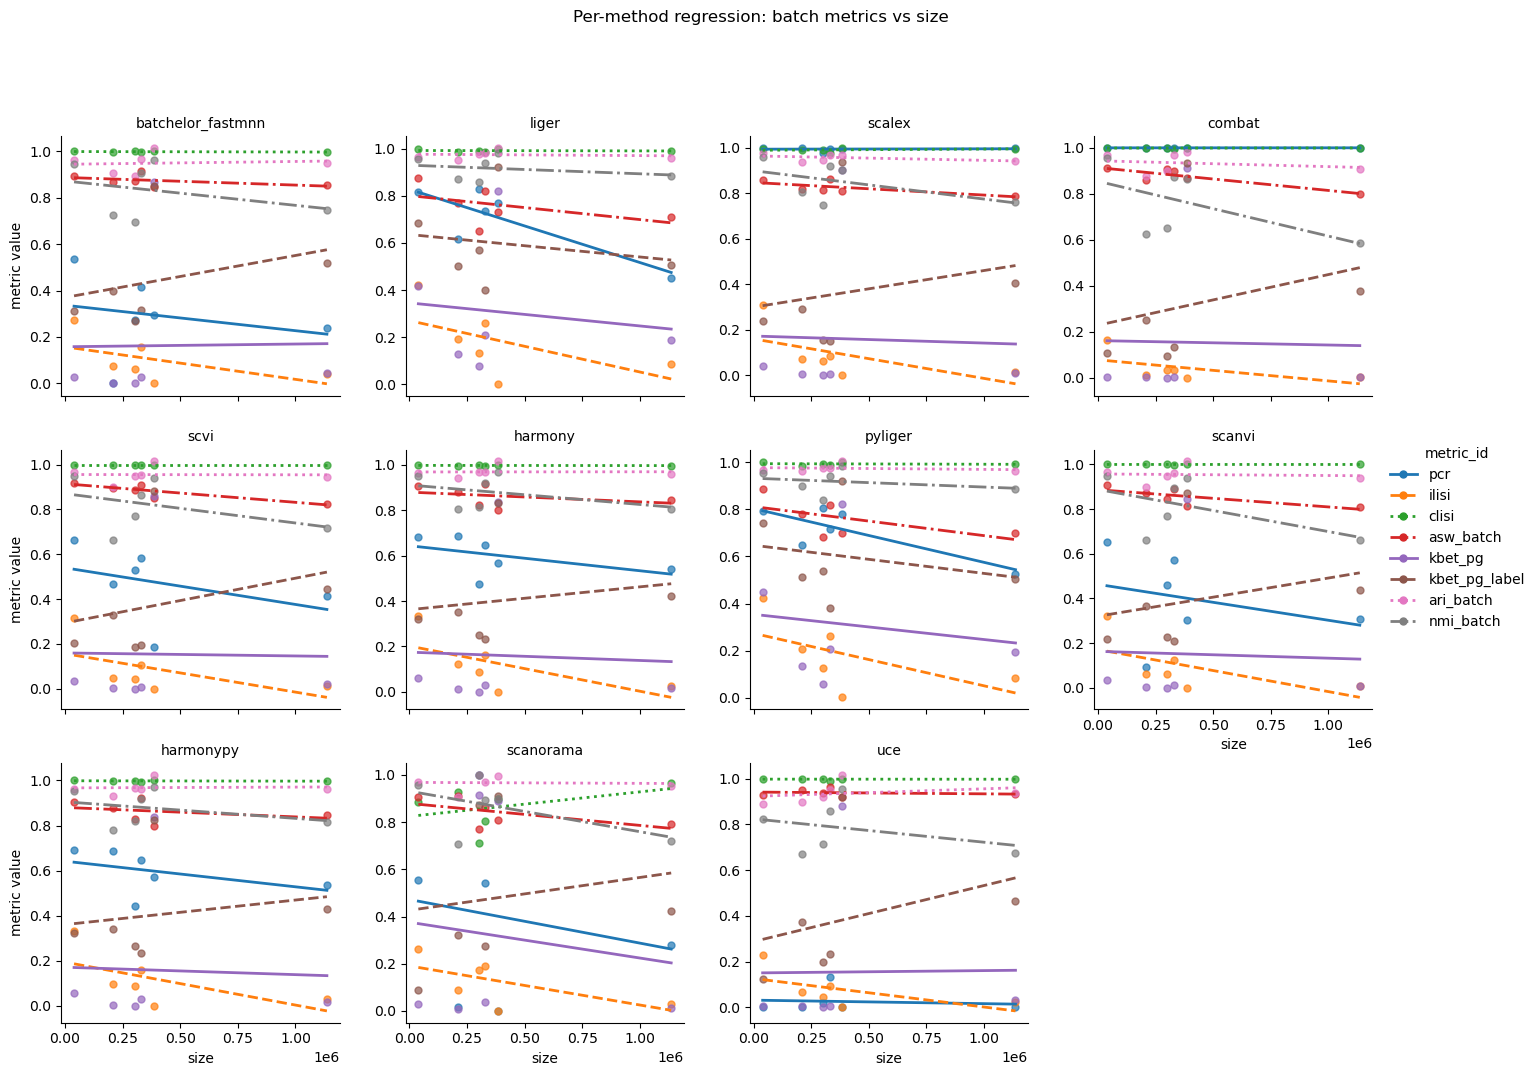

In [50]:
df_batch = df_plot.query("metric_type == 'batch'")
df_batch = df_batch[df_batch["control_group"] == "non-control method"]

metric_order = [m for m in batch_metrics if m in df_batch["metric_id"].unique()]
palette = sns.color_palette("tab10", n_colors=len(metric_order))
line_styles = ["-", "--", ":", "-."]

# map metric -> color
color_map = dict(zip(metric_order, palette))

# --------- FACETGRID WITHOUT HUE ----------
g = sns.FacetGrid(
    df_batch,
    col="method_id",
    col_wrap=4,
    height=3.5,
    sharex=True,
    sharey=False,
)

# --------- PLOT EACH METRIC MANUALLY ----------
def reg_all_metrics(data, **kwargs):
    # data = one method (facet)
    for i, metric in enumerate(metric_order):
        df_m = data[data["metric_id"] == metric]
        if df_m.empty:
            continue

        color = color_map[metric]
        style = line_styles[i % len(line_styles)]

        sns.regplot(
            data=df_m,
            x="size",
            y="metric_value",
            ci=None,
            scatter=True,
            color=color,   # YOUR color
            scatter_kws={"s": 25, "alpha": 0.7},
            line_kws={"linestyle": style, "linewidth": 2},
        )

g.map_dataframe(reg_all_metrics)

# --------- LEGEND ----------
handles = [
    Line2D(
        [0], [0],
        color=color_map[m],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=2,
        marker="o",
        markersize=5,
        label=m,
    )
    for i, m in enumerate(metric_order)
]

g.add_legend(handles=handles, title="metric_id")

g.set_axis_labels("size", "metric value")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Per-method regression: batch metrics vs size", y=1.02)

plt.show()

g.savefig("/Users/seohyon/seocodes/ba_interpretable_opsca/notebooks/figures/size_subplot_method_batch.png", dpi=300)

- clisi, ari_batch performs very well and consistently with all methods (but no slope - no tendency)

- pcr, asw_batch: negative correlation with most of the methods

- ari_label, kbet_pg_label goes against the trend (is positive correlation): UNDERSTAND

We seem to find consistent trends with this specific feature, which means dataset size has an effect on the integration irrespective of the integration method.

Modell 1) all methods together 2)consider method differences
    add the method itself as an interaction term, so you have 1 model per feature that accounts for multiple methods (instead of one model per method)
    distinguish between control and non-control methods (esp if they show different trends)


In [101]:
df_plot

,dataset_id,method_id,metric_id,metric_value,organism,n_tissues,size,n_genes,n_celltypes,n_batches,batch_imbalance_cv,batch_imbalance_gc,nested_batches,n_samples,n_donors,control_type,control_group,nested_batches_num,metric_type,metric_group
0,gtex_v9,embed_cell_types,ilisi,0.116225,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
1,gtex_v9,embed_cell_types,clisi,1.000000,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,positive,control method,1,batch,batch
2,hypomap,batchelor_fastmnn,ilisi,0.000518,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
3,hypomap,batchelor_fastmnn,clisi,1.000000,Mouse,1,384925,51216,13,24,4.40,0.908038,No,126.0,24,non-control,non-control method,0,batch,batch
4,mouse_pancreas_atlas,embed_cell_types_jittered,cell_cycle_conservation,0.681843,Mouse,1,301796,31202,20,56,0.66,0.354691,Yes,56.0,56,positive,control method,1,bio,bio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,tabula_sapiens,pyliger,ari_batch,0.960975,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1492,tabula_sapiens,pyliger,nmi_batch,0.886413,Human,75,1136218,60606,180,24,1.35,0.642039,No,658.0,24,non-control,non-control method,0,batch,batch
1493,immune_cell_atlas,embed_cell_types_jittered,kbet_pg,0.274452,Human,17,329762,35469,35,12,0.96,0.460000,No,NaN,12,positive,control method,0,batch,batch
1494,gtex_v9,scalex,isolated_label_f1,0.016119,Human,8,209126,32088,53,16,1.00,0.494784,Yes,25.0,16,non-control,non-control method,1,bio,bio


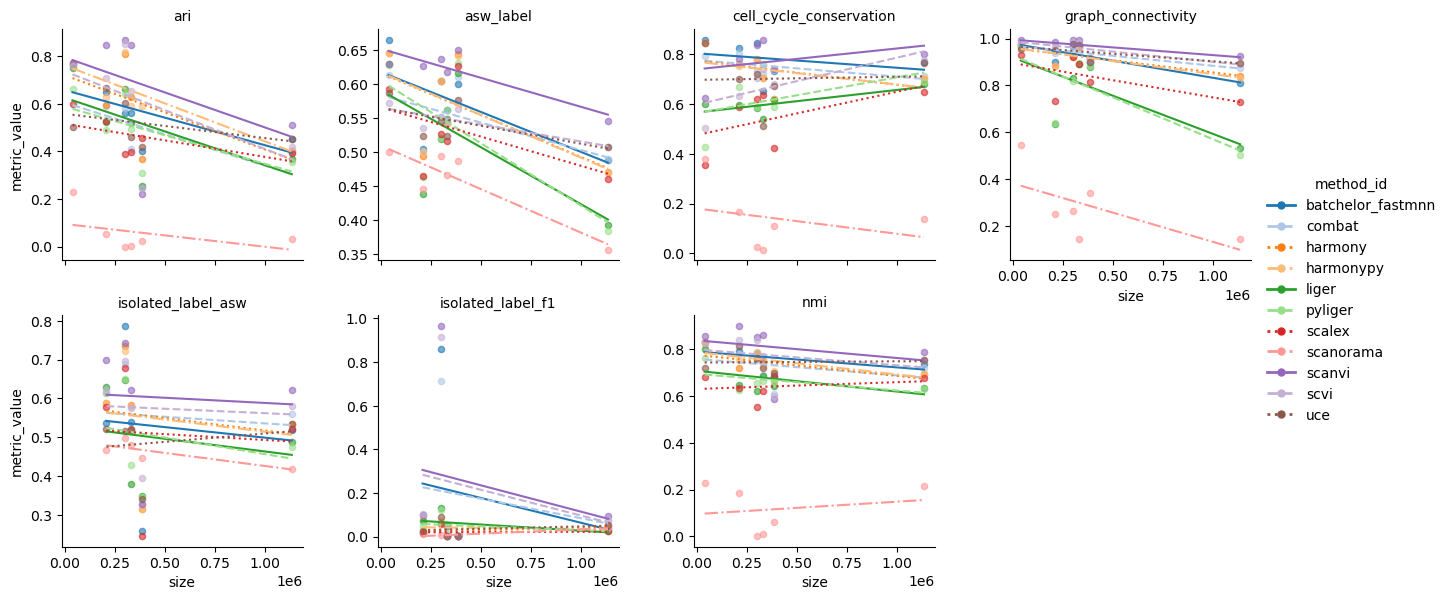

In [121]:
metric_vs_feature_by_method_facet(df_plot.query("control_type == 'non-control' and metric_type == 'bio'"), "size", save="noncontrol_vs_size_per_bio_metric")

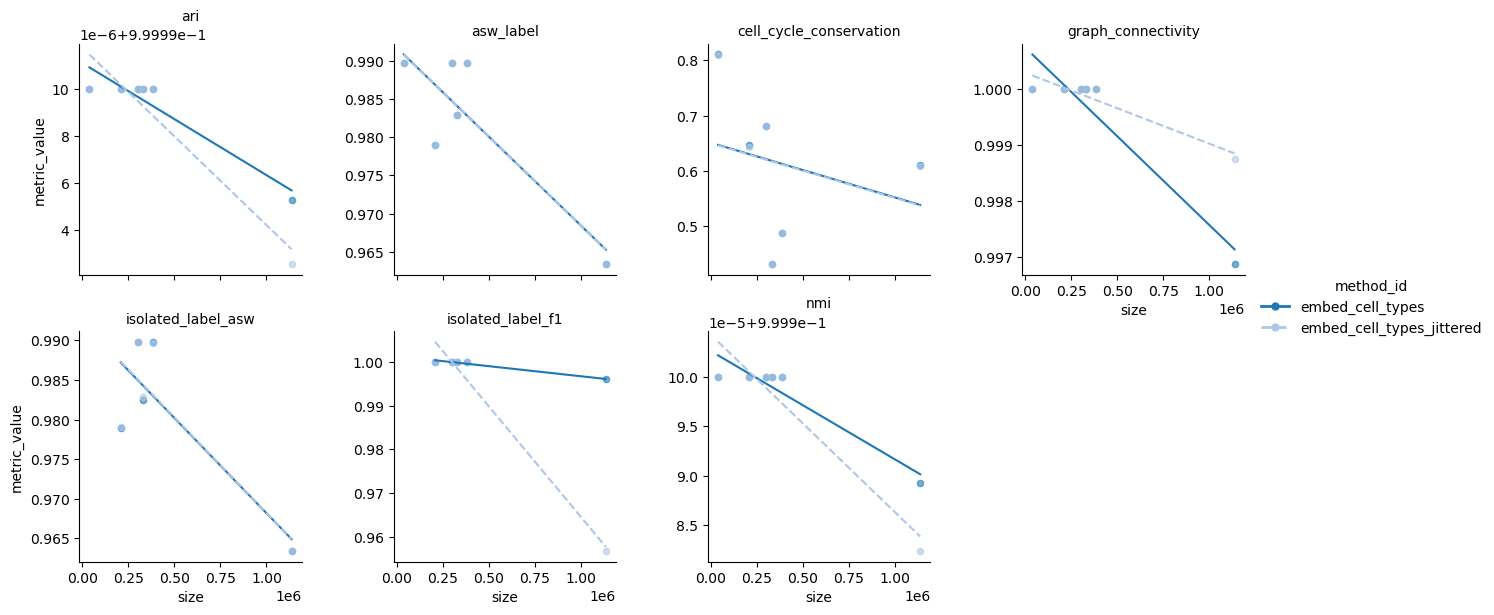

In [125]:
metric_vs_feature_by_method_facet(df_plot.query("control_type == 'positive' and metric_type == 'bio'"), "size", save="positive_vs_size_per_bio_metric")

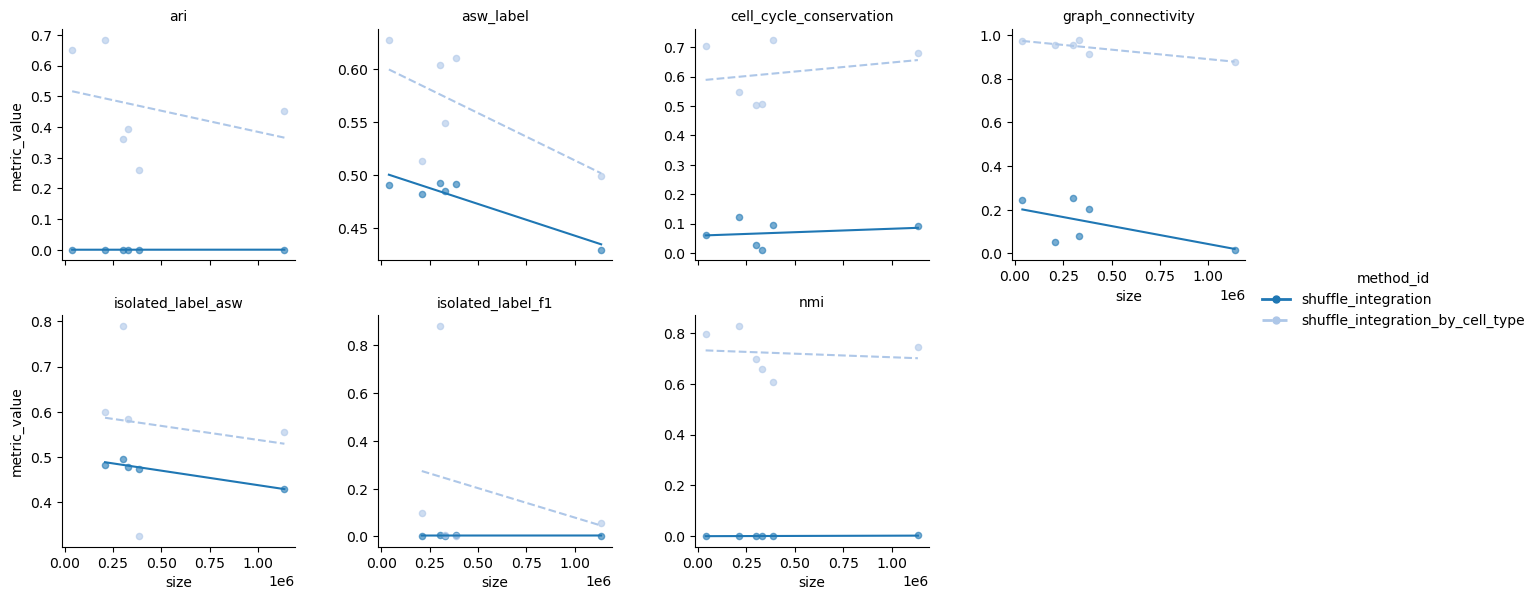

In [126]:
metric_vs_feature_by_method_facet(df_plot.query("control_type == 'negative' and metric_type == 'bio'"), "size", save="negative_vs_size_per_bio_metric")

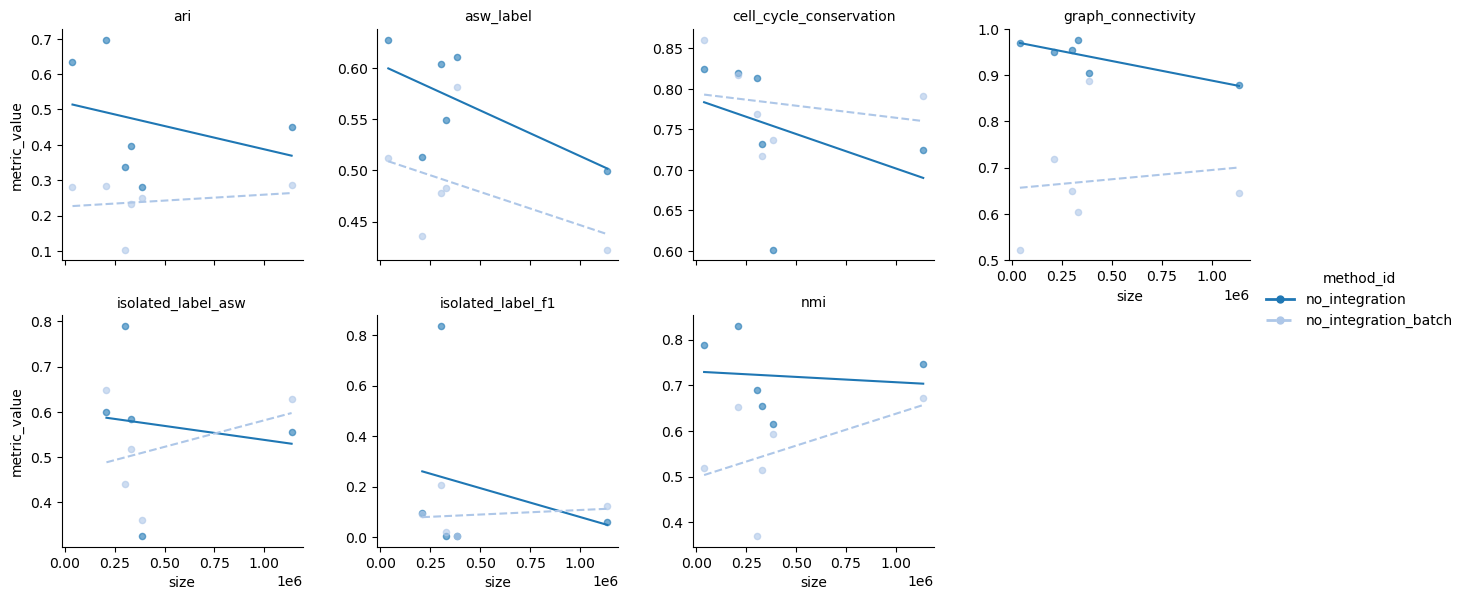

In [127]:
metric_vs_feature_by_method_facet(df_plot.query("control_type == 'baseline' and metric_type == 'bio'"), "size", save="baseline_vs_size_per_bio_metric")

### one metric x n_genes per method - all together

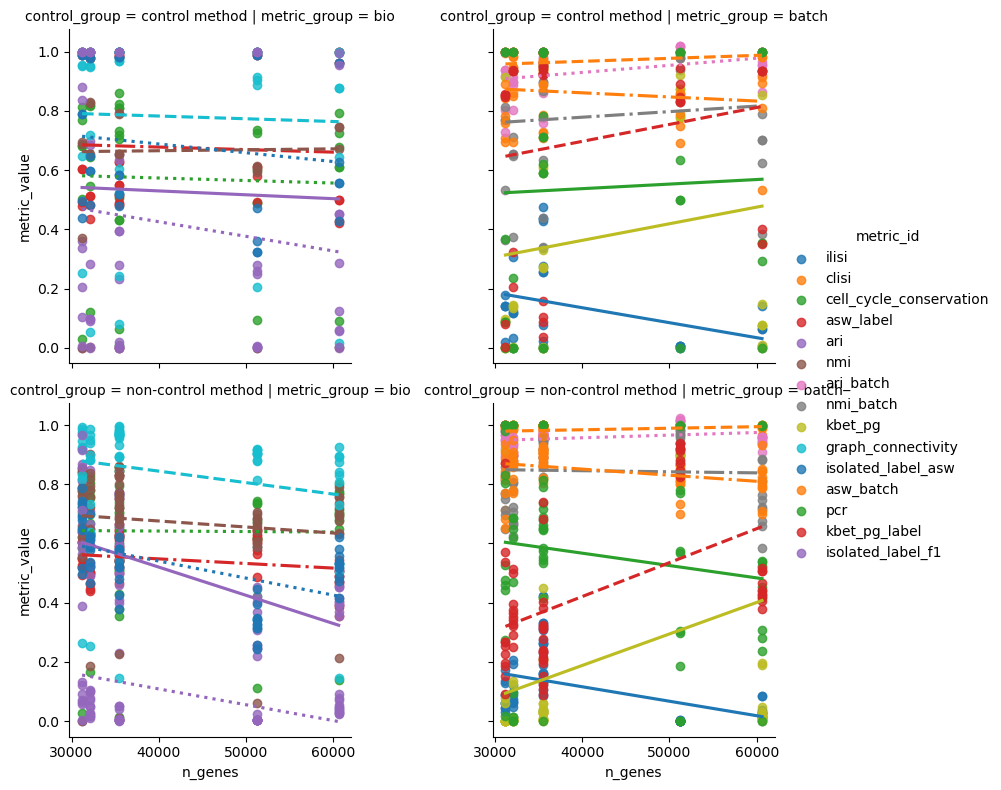

In [220]:
g = sns.FacetGrid(
    df_plot,
    row="control_group",         # control vs non-control
    col="metric_group",          # bio vs batch
    hue="metric_id",
    height=4,
    palette=palette,
    row_order=["control method", "non-control method"],
    col_order=["bio", "batch"],
    # subplot_kws={"wspace": 0.3},
)

def reg_with_style(data, color, label, **kwargs):
    # Use global df just to get consistent index for line_styles
    idx = list(df["metric_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_genes",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={"linestyle": style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

g.fig.subplots_adjust(wspace=0.5)

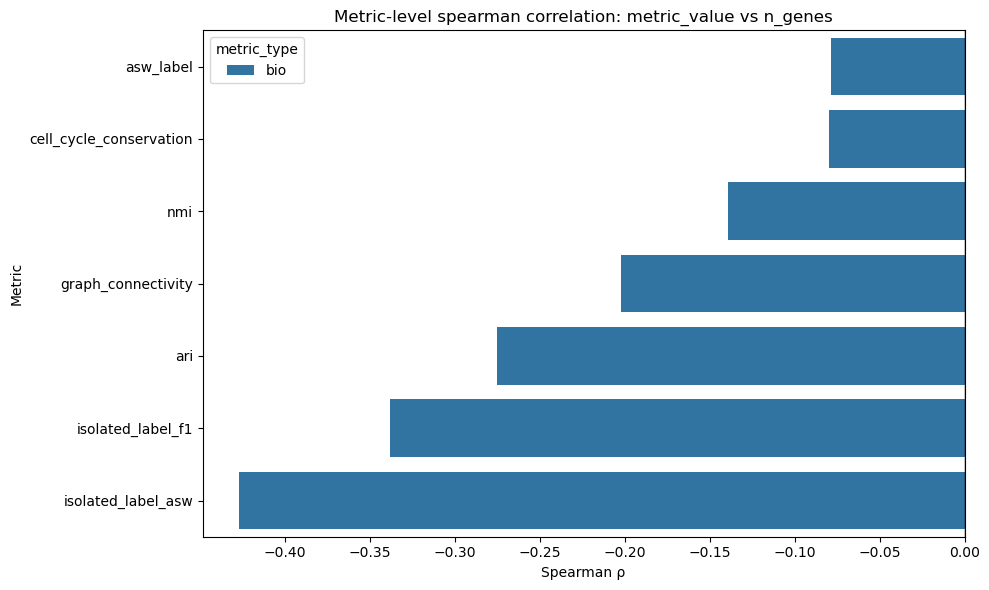

,metric_id,spearman_rho,p_value,n_points,metric_type,feature
1,asw_label,-0.078335,0.433862,102,bio,n_genes
0,cell_cycle_conservation,-0.079720,0.425754,102,bio,n_genes
3,nmi,-0.138984,0.163578,102,bio,n_genes
4,graph_connectivity,-0.202065,0.041684,102,bio,n_genes
2,ari,-0.275390,0.005088,102,bio,n_genes
6,isolated_label_f1,-0.338514,0.001530,85,bio,n_genes
5,isolated_label_asw,-0.427209,0.000046,85,bio,n_genes


In [248]:
spearman_by_metric(df_plot.query("metric_group == 'bio'"), "n_genes")

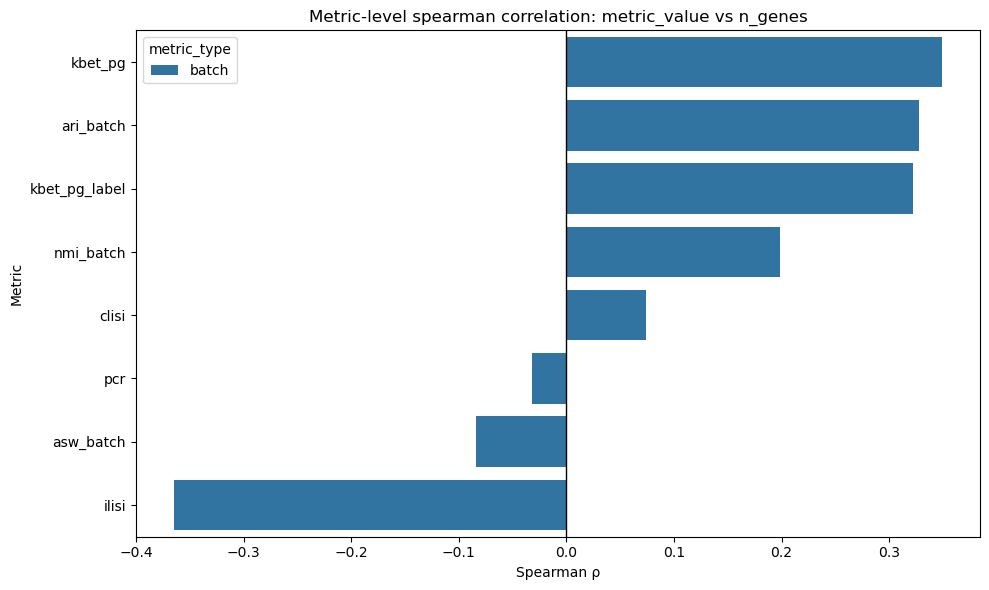

,metric_id,spearman_rho,p_value,n_points,metric_type,feature
4,kbet_pg,0.348806,0.000327,102,batch,n_genes
2,ari_batch,0.328182,0.000759,102,batch,n_genes
7,kbet_pg_label,0.322639,0.000942,102,batch,n_genes
3,nmi_batch,0.198314,0.045708,102,batch,n_genes
1,clisi,0.074147,0.458913,102,batch,n_genes
6,pcr,-0.032264,0.747513,102,batch,n_genes
5,asw_batch,-0.084171,0.400291,102,batch,n_genes
0,ilisi,-0.364584,0.000165,102,batch,n_genes


In [247]:
spearman_by_metric(df_plot.query("metric_group == 'batch'"), "n_genes")

### bio-metrics vs features all together

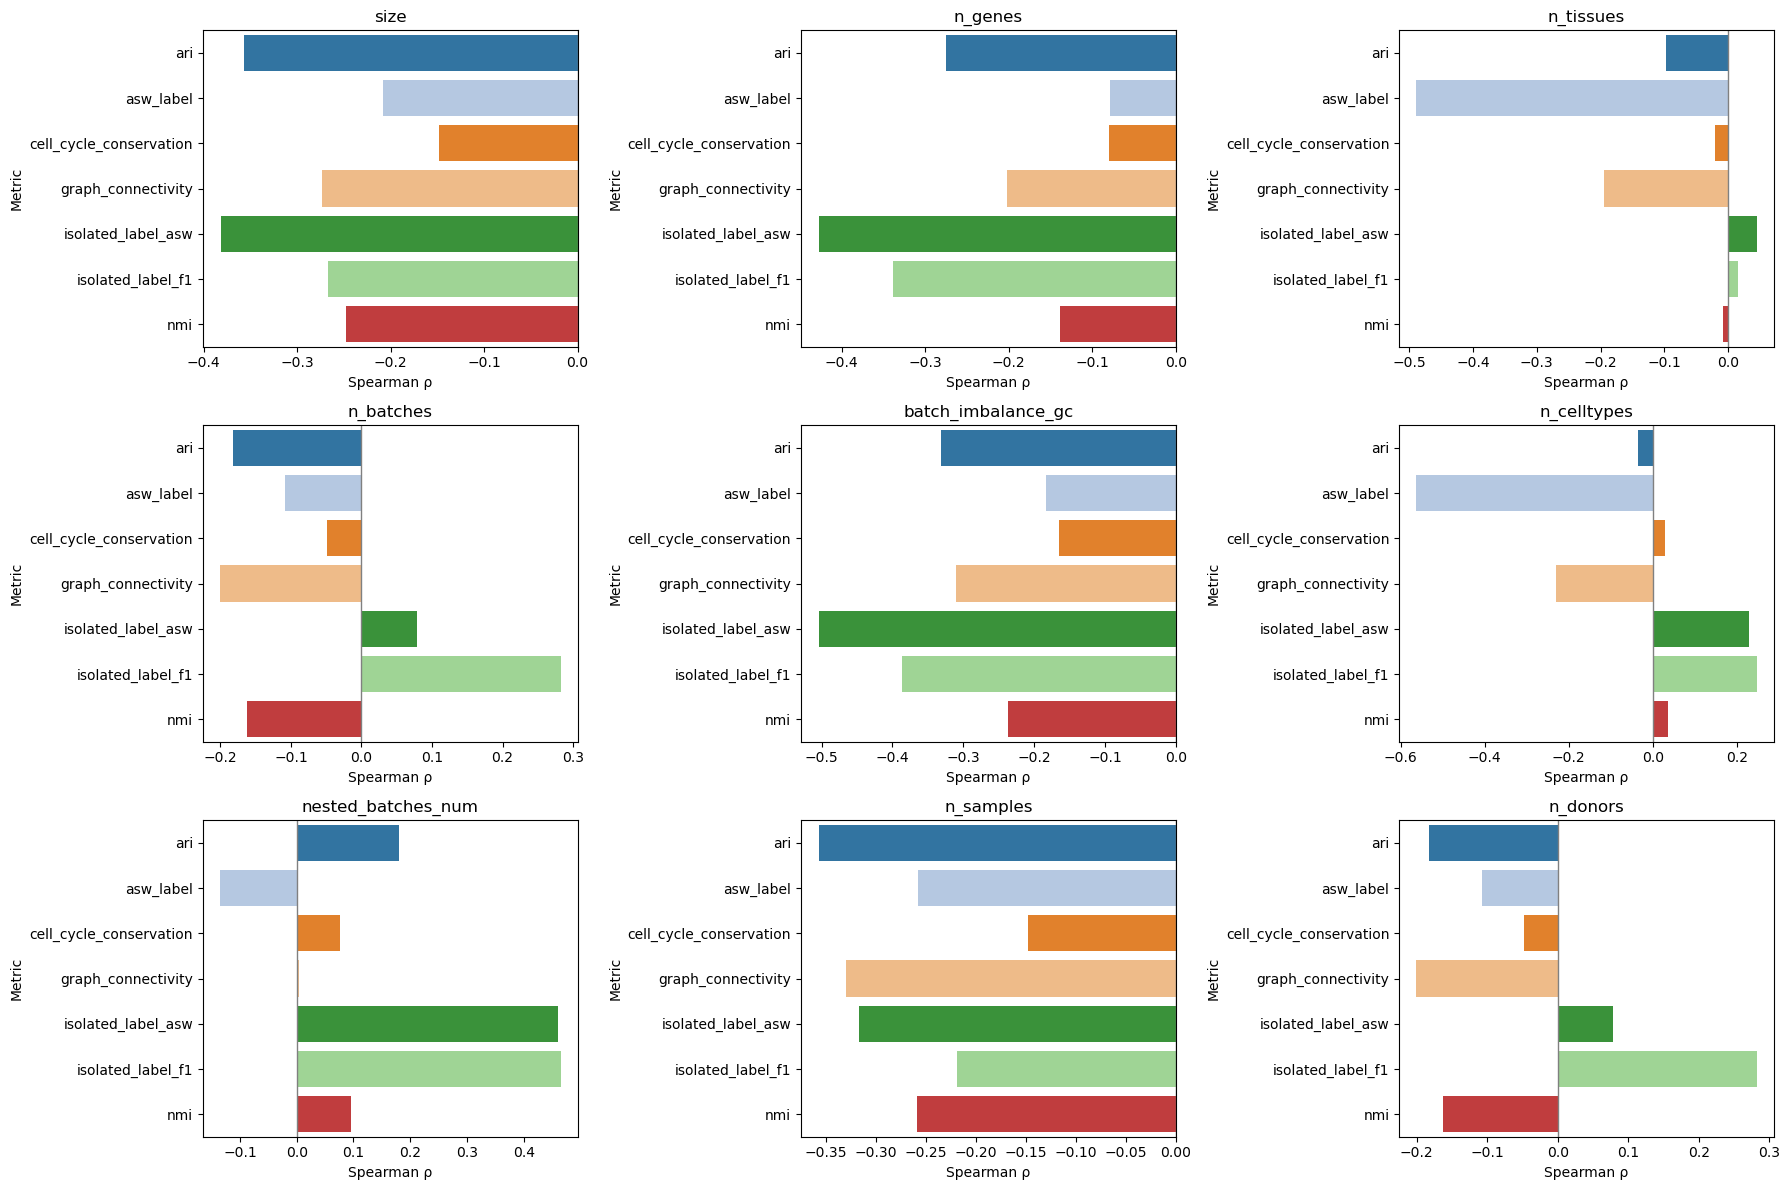

In [281]:
features = ["size", "n_genes", "n_tissues", "n_batches", "batch_imbalance_gc", "n_celltypes", "nested_batches_num", "n_samples", "n_donors"]

df_corr = spearman_by_metric_multi(df_plot.query("metric_group == 'bio'"), features, save=True)


But the correlation is not that high in any of these

### batch-metrics vs features all together

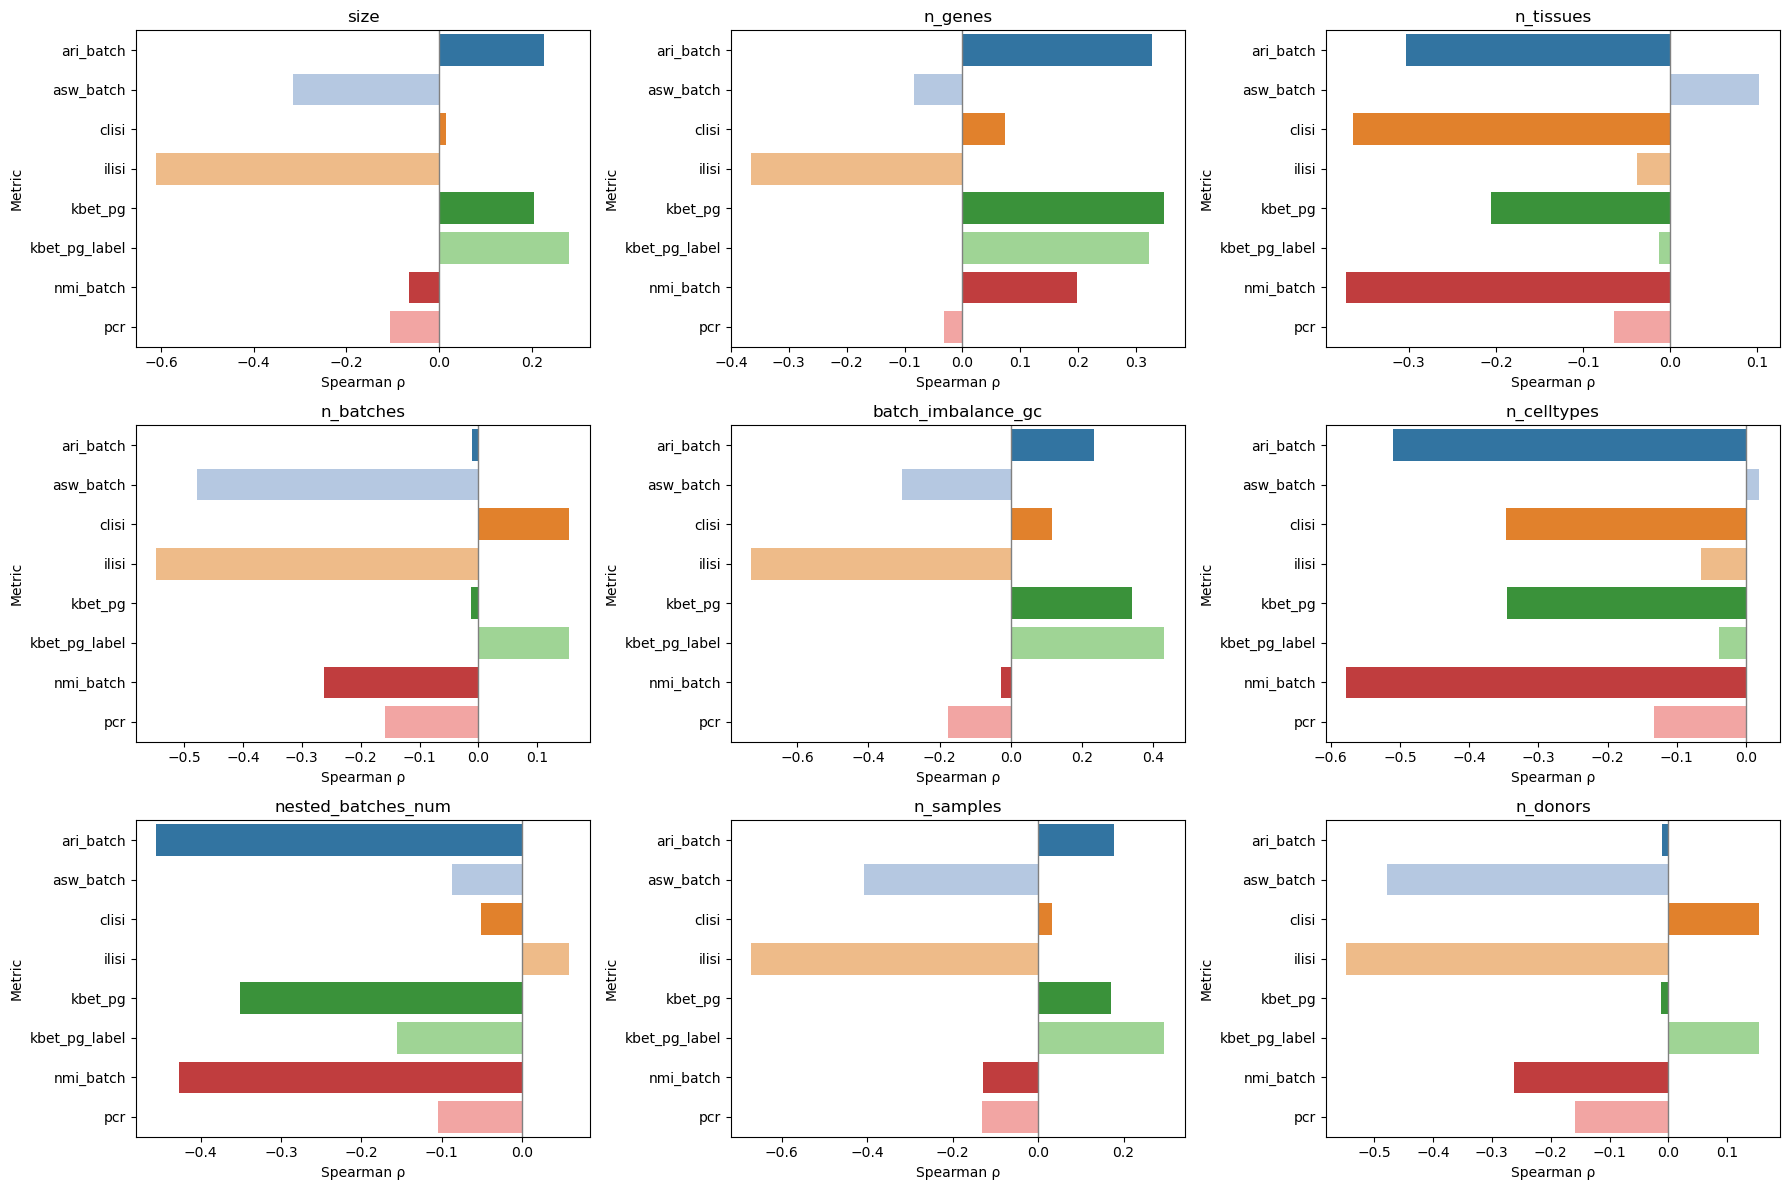

In [283]:
df_corr = spearman_by_metric_multi(df_plot.query("metric_group == 'batch'"), features, save=True)